# Trabajo Final - Aprendizaje de Máquina  - CEIA - MCB

## **Título:** 

## Predicción de demanda operativa y priorización de inversión en infraestructura mediante aprendizaje automático

### **Caso de estudio sobre reclamos, precipitación y costo operativo en la Cooperativa de Electricidad de Montecarlo Limitada (CEML)**


### **Autor:** Martín Anibal Lacheski  


#### **Universidad:** Universidad de Buenos Aires


#### **Carreras:**
#### - Carrera de Especialización en Inteligencia Artificial
#### - Maestría en Computación de Borde

---

> ### Hoja de ruta del trabajo
>
> El presente notebook está organizado como **informe final completo**.
>
> En primer lugar se introduce el problema y se explicita la motivación operativa del estudio. Luego se describen las fuentes de datos, el pipeline de construcción analítica y las decisiones metodológicas que permiten arribar al dataset final de modelado. A continuación se desarrolla el análisis exploratorio, se establece un baseline heurístico, se entrenan modelos supervisados, se comparan sus resultados y se traducen los hallazgos a conclusiones operativas, lectura territorial y mapas finales de priorización.


## Resumen Ejecutivo

- **Problema de negocio.** CEML necesita anticipar presión operativa futura por zona para mejorar la priorización de mantenimiento, despliegue de cuadrillas e inversión territorial.
- **Fuentes utilizadas.** El análisis integra reclamos georreferenciados, precipitación, referencias geográficas/ruteo y una capa de costo operativo provista por la cooperativa.
- **Mejor modelo.** **XGBoost** resulta el mejor candidato en los tres targets evaluados, con WMAPE de **0.602** para reclamos, **0.621** para tiempo operativo y **0.632** para costo, superando al baseline heurístico.
- **Hallazgo territorial principal.** Las **zonas lejanas** concentran el **56.2%** de los reclamos, el **52.0%** del costo y el **53.9%** del tiempo operativo; dentro de la segmentación fina, el **Q4 más lejano** explica por sí solo **47.5%** de los reclamos y **44.4%** del tiempo total.
- **Recomendación práctica.** Utilizar el modelo como soporte de decisión para focalizar primero en zonas donde coinciden alta carga operativa y mayor exigencia territorial, en lugar de distribuir recursos de forma homogénea.
- **Cautela metodológica.** Los resultados son promisorios, pero todavía deben validarse con esquemas temporales y controles de calidad de datos antes de un uso productivo.


In [65]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
elif (ROOT / 'ceia-amq-tp' / 'data').exists():
    ROOT = ROOT / 'ceia-amq-tp'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from helpers.eda_utils import get_zone_name, apply_zone_names

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

## 1. Introducción

La operación de una cooperativa de servicios de agua, cloacas, electricidad, internet y cable;  combina restricciones territoriales, variabilidad climática, demanda heterogénea y costos logísticos que no siempre resultan visibles a simple vista. En ese contexto, la capacidad de anticipar qué zonas presentarán mayor presión operativa futura constituye un insumo valioso para orientar decisiones de inversión, mantenimiento preventivo y asignación de recursos.

Este trabajo aborda el caso de la Cooperativa de Electricidad de Montecarlo Limitada (CEML) a partir de registros de reclamos georreferenciados, datos de precipitación y una capa de costeo operativo construida sobre distancias, tiempos y criterios de atención. El objetivo no es únicamente describir el comportamiento histórico, sino también sentar las bases para un esquema de predicción que permita priorizar zonas con mayor impacto potencial sobre el servicio.

## 2. Planteo del problema

CEML enfrenta una dinámica operativa donde los reclamos no se distribuyen de manera uniforme ni en el espacio ni en el tiempo. Existen zonas con mayor recurrencia, jornadas sensibles a precipitaciones intensas y diferencias relevantes en costo y tiempo de resolución según la localización de los eventos. Esta combinación vuelve insuficiente una lectura puramente descriptiva del histórico.

Desde una perspectiva de gestión, la pregunta central es la siguiente: **¿qué zonas deberían priorizarse para intervenciones de infraestructura u operación cuando se consideran simultáneamente la demanda futura, el tiempo operativo esperado y el costo asociado a esa atención?** Responder esta pregunta exige transformar múltiples fuentes heterogéneas en una unidad analítica consistente y apta para modelado.

## 3. Objetivo general

Desarrollar una base metodológica y analítica para predecir demanda operativa futura por zona, integrando reclamos georreferenciados, precipitación y costo operativo, con el fin de apoyar la priorización de inversión en infraestructura y decisiones de gestión en la Cooperativa Eléctrica de Montecarlo Limitada.

## 4. Objetivos específicos

- Consolidar un pipeline reproducible de integración entre reclamos, lluvia, referencias geográficas y costeo operativo.
- Construir una unidad analítica `zona-diario` que permita describir y modelar la evolución temporal de la demanda operativa.
- Definir variables objetivo alineadas con el problema de negocio: tiempo operativo futuro, costo operativo futuro y cantidad futura de reclamos.
- Describir la cobertura temporal y territorial del dataset final, identificando sesgos, limitaciones y fortalezas analíticas.
- Preparar una estructura de análisis exploratorio y modelado que permita comparar distintos enfoques predictivos en etapas posteriores del trabajo.

## 5. Estructura del trabajo

El informe se organiza en una secuencia que sigue la lógica habitual de un trabajo final aplicado en aprendizaje automático. En primer término se presenta el problema y su motivación operativa. Luego se documentan las fuentes de datos y el proceso de construcción del dataset analítico. A continuación se introduce el dataset final, se desarrolla el análisis exploratorio, se define un baseline heurístico y se entrenan modelos supervisados para los tres targets del caso.

Sobre esa base, el notebook cierra con la comparación entre enfoques, la selección del mejor modelo, una síntesis territorial orientada a inversión y una recomendación final para CEML. De este modo, el documento cumple una doble función: actuar como soporte de redacción académica y, al mismo tiempo, mantener un vínculo explícito con la trazabilidad computacional del proyecto.


## 6. Nota metodológica sobre notebooks de apoyo

La construcción del caso no se realizó en un único cuaderno, sino mediante una secuencia de notebooks especializados que funcionaron como soporte metodológico y de reproducibilidad. En particular, los notebooks `1_ingesta_depuration.ipynb`, `2_lluvia_depuration.ipynb`, `3_costeo_ruteo.ipynb` y `4_exploracion.ipynb` documentan etapas específicas del procesamiento, la depuración, la integración de fuentes y la exploración inicial.

En este informe final dichos notebooks deben leerse como **anexos metodológicos**: no reemplazan la narrativa principal, pero sí respaldan la trazabilidad de las transformaciones aplicadas y permiten reconstruir el pipeline de datos desde los insumos originales hasta la unidad analítica final.

## 7. Trazabilidad y construcción del dataset

La calidad analítica de este trabajo depende no solo del desempeño de los modelos que se evaluarán más adelante, sino también de la trazabilidad de las fuentes y de la forma en que esas fuentes fueron transformadas en un dataset apto para análisis y predicción. En este sentido, el caso de CEML combina insumos de naturaleza muy distinta —registros operativos internos, documentos climáticos históricos, información de ruteo y referencias de costo— que debieron ser integrados bajo un criterio común de consistencia temporal y territorial.

Los **reclamos** provienen del sistema de gestión interno de la Cooperativa de Electricidad de Montecarlo Limitada. A partir de esas tablas operativas, se realizó un proceso de consolidación y depuración que permitió normalizar los registros involucrados y persistirlos en formato `.parquet`, facilitando su posterior integración con el resto de las fuentes.

La **información de lluvia** presenta una trazabilidad particular, ya que el registro primario se conserva como documentación mensual en soporte papel. Para incorporarlo al pipeline analítico fue necesario digitalizarlo y extraer su contenido mediante scripts específicos y el uso de la **Google GenAI API**, empleando como modelo principal **Gemini 2.5 Flash** y, cuando resultó necesario, un esquema de fallback con **Gemini 2.0 Flash**. Esta etapa permitió convertir un insumo originalmente no estructurado en una serie diaria utilizable dentro del análisis.

Las variables de **distancia y tiempo de traslado** se obtuvieron mediante la **Google Maps Directions API**, lo que permitió construir una capa operativa consistente para estimar recorridos, tiempos de atención y carga logística asociada a los reclamos.

Por último, la capa de **costo de mano de obra y costo operativo** se construyó a partir de información interna provista por la cooperativa. Esa información fue integrada con los componentes de traslado y resolución para obtener una medida monetaria comparable entre zonas y períodos.

En conjunto, estas fuentes conforman una cadena de trazabilidad que va desde el dato operativo original hasta la unidad analítica final utilizada en este informe. La sección siguiente describe cómo esa cadena se transformó efectivamente en el dataset de trabajo.

In [66]:
expected_artifacts = {
    'notebook_ingesta': ROOT / 'notebooks/1_ingesta_depuration.ipynb',
    'notebook_lluvia': ROOT / 'notebooks/2_lluvia_depuration.ipynb',
    'notebook_costeo': ROOT / 'notebooks/3_costeo_ruteo.ipynb',
    'notebook_exploracion': ROOT / 'notebooks/4_exploracion.ipynb',
    'reclamos_clean': ROOT / 'data/processed/reclamos_clean.parquet',
    'lluvia_diaria_clean': ROOT / 'data/processed/lluvia_diaria_clean.parquet',
    'distancias_costos': ROOT / 'data/processed/distancias_costos.parquet',
    'zona_diario_base': ROOT / 'data/processed/zona_diario_base.parquet',
    'zona_diario_supervisado': ROOT / 'data/processed/zona_diario_supervisado.parquet',
    'zona_cluster_resumen': ROOT / 'data/processed/zona_cluster_resumen.parquet',
}

pd.DataFrame({
    'artifacto': list(expected_artifacts.keys()),
    'ruta_esperada': [str(path.relative_to(ROOT)) for path in expected_artifacts.values()],
    'existe': [path.exists() for path in expected_artifacts.values()],
})

,artifacto,ruta_esperada,existe
0,notebook_ingesta,notebooks/1_ingesta_depuration.ipynb,True
1,notebook_lluvia,notebooks/2_lluvia_depuration.ipynb,True
2,notebook_costeo,notebooks/3_costeo_ruteo.ipynb,True
3,notebook_exploracion,notebooks/4_exploracion.ipynb,True
4,reclamos_clean,data/processed/reclamos_clean.parquet,True
5,lluvia_diaria_clean,data/processed/lluvia_diaria_clean.parquet,True
6,distancias_costos,data/processed/distancias_costos.parquet,True
7,zona_diario_base,data/processed/zona_diario_base.parquet,True
8,zona_diario_supervisado,data/processed/zona_diario_supervisado.parquet,True
9,zona_cluster_resumen,data/processed/zona_cluster_resumen.parquet,True


## 8. Pipeline de construcción de datos

A partir de las fuentes y criterios de trazabilidad descriptos en la sección anterior, el pipeline de construcción de datos siguió una lógica secuencial orientada a preservar consistencia, auditabilidad y utilidad analítica. En primer lugar se abordó la normalización e ingestión de los registros operativos, poniendo especial atención en la consistencia de fechas, identificadores y localización geográfica. Luego se incorporó la dimensión climática mediante la digitalización, depuración y estandarización de los registros de precipitación.

En una etapa posterior se construyó la capa de costeo operativo, articulando referencias territoriales, distancias, tiempos de traslado y reglas de asignación de costo provistas por la cooperativa. Finalmente, todos estos insumos fueron integrados en una unidad analítica diaria por zona, lo que permitió derivar lags, agregados móviles y variables objetivo futuras para su eventual uso en modelos de predicción.

Desde el punto de vista metodológico, esta secuencia garantiza separación entre procesamiento fuente, enriquecimiento contextual y construcción del dataset supervisado final.

## 9. Descripción del dataset final

El dataset final del trabajo resume la dinámica operativa en la unidad `zona-diario`, donde cada fila representa una zona operativa en una fecha determinada. Sobre esa estructura se consolidan variables descriptivas, señales de demanda reciente, atributos climáticos y componentes de costo, junto con las variables objetivo que permiten plantear un problema supervisado de predicción a horizonte corto.

Esta organización tiene dos ventajas principales. En primer lugar, habilita comparaciones homogéneas entre zonas con distinta intensidad histórica. En segundo lugar, reduce el riesgo de leakage al permitir que las variables predictoras se construyan con información disponible hasta el corte temporal correspondiente.

## 10. Análisis exploratorio de datos

El análisis exploratorio constituye una instancia clave para validar la coherencia del dataset final, reconocer patrones dominantes y detectar relaciones potencialmente útiles para el modelado. En esta etapa no se busca todavía optimizar un algoritmo, sino comprender la estructura del problema y justificar, con evidencia empírica, las decisiones analíticas posteriores.

In [67]:
processed_paths = {
    'reclamos_clean': ROOT / 'data/processed/reclamos_clean.parquet',
    'reclamos_enriquecidos': ROOT / 'data/processed/reclamos_enriquecidos.parquet',
    'reclamos_zonificados': ROOT / 'data/processed/reclamos_zonificados.parquet',
    'lluvia_diaria_clean': ROOT / 'data/processed/lluvia_diaria_clean.parquet',
    'zona_diario_base': ROOT / 'data/processed/zona_diario_base.parquet',
    'zona_diario_supervisado': ROOT / 'data/processed/zona_diario_supervisado.parquet',
}

assert processed_paths['reclamos_clean'].exists(), 'Falta reclamos_clean.parquet'
assert processed_paths['lluvia_diaria_clean'].exists(), 'Falta lluvia_diaria_clean.parquet'
assert processed_paths['zona_diario_base'].exists(), 'Falta zona_diario_base.parquet'
assert processed_paths['zona_diario_supervisado'].exists(), 'Falta zona_diario_supervisado.parquet'

reclamos_clean = pd.read_parquet(processed_paths['reclamos_clean'])
lluvia_diaria_clean = pd.read_parquet(processed_paths['lluvia_diaria_clean'])
zona_diario_base = pd.read_parquet(processed_paths['zona_diario_base'])
zona_diario_supervisado = pd.read_parquet(processed_paths['zona_diario_supervisado'])

reclamos_geo_path = processed_paths['reclamos_enriquecidos'] if processed_paths['reclamos_enriquecidos'].exists() else processed_paths['reclamos_zonificados']
reclamos_geo = pd.read_parquet(reclamos_geo_path)

for df_name in ['lluvia_diaria_clean', 'zona_diario_base', 'zona_diario_supervisado']:
    if 'fecha' in locals()[df_name].columns:
        locals()[df_name]['fecha'] = pd.to_datetime(locals()[df_name]['fecha'])

if 'fecha_reclamo' in reclamos_clean.columns:
    reclamos_clean['fecha_reclamo'] = pd.to_datetime(reclamos_clean['fecha_reclamo'])
    reclamos_clean['fecha'] = reclamos_clean['fecha_reclamo'].dt.floor('D')
elif 'fecha' in reclamos_clean.columns:
    reclamos_clean['fecha'] = pd.to_datetime(reclamos_clean['fecha'])

if 'fecha' in reclamos_geo.columns:
    reclamos_geo['fecha'] = pd.to_datetime(reclamos_geo['fecha'])
elif 'fecha_reclamo' in reclamos_geo.columns:
    reclamos_geo['fecha_reclamo'] = pd.to_datetime(reclamos_geo['fecha_reclamo'])
    reclamos_geo['fecha'] = reclamos_geo['fecha_reclamo'].dt.floor('D')

pd.DataFrame({
    'artifacto': ['reclamos_clean', reclamos_geo_path.stem, 'lluvia_diaria_clean', 'zona_diario_base', 'zona_diario_supervisado'],
    'ruta': [
        str(processed_paths['reclamos_clean'].relative_to(ROOT)),
        str(reclamos_geo_path.relative_to(ROOT)),
        str(processed_paths['lluvia_diaria_clean'].relative_to(ROOT)),
        str(processed_paths['zona_diario_base'].relative_to(ROOT)),
        str(processed_paths['zona_diario_supervisado'].relative_to(ROOT)),
    ]
})

,artifacto,ruta
0,reclamos_clean,data/processed/reclamos_clean.parquet
1,reclamos_enriquecidos,data/processed/reclamos_enriquecidos.parquet
2,lluvia_diaria_clean,data/processed/lluvia_diaria_clean.parquet
3,zona_diario_base,data/processed/zona_diario_base.parquet
4,zona_diario_supervisado,data/processed/zona_diario_supervisado.parquet


### 10.1 Cobertura temporal y territorial

Esta subsección busca responder una pregunta básica pero decisiva antes de cualquier modelado: **qué tan representativo es el universo analítico que efectivamente quedó disponible para el estudio**. En términos prácticos, interesa observar la amplitud temporal cubierta por los registros, la cantidad de zonas retenidas y la distribución territorial de la carga operativa. Esta caracterización permite distinguir si el dataset final refleja un fenómeno estable y suficientemente amplio, o si por el contrario está sesgado hacia períodos o sectores muy específicos del territorio.

In [68]:
coverage_summary = pd.DataFrame([
    {
        'dataset': 'reclamos_clean',
        'filas': len(reclamos_clean),
        'fecha_min': reclamos_clean['fecha'].min(),
        'fecha_max': reclamos_clean['fecha'].max(),
        'zonas_unicas': pd.NA,
        'dias_modelado': reclamos_clean['fecha'].nunique(),
    },
    {
        'dataset': reclamos_geo_path.stem,
        'filas': len(reclamos_geo),
        'fecha_min': reclamos_geo['fecha'].min(),
        'fecha_max': reclamos_geo['fecha'].max(),
        'zonas_unicas': reclamos_geo['zona_id'].nunique() if 'zona_id' in reclamos_geo.columns else pd.NA,
        'dias_modelado': reclamos_geo['fecha'].nunique(),
    },
    {
        'dataset': 'lluvia_diaria_clean',
        'filas': len(lluvia_diaria_clean),
        'fecha_min': lluvia_diaria_clean['fecha'].min(),
        'fecha_max': lluvia_diaria_clean['fecha'].max(),
        'zonas_unicas': pd.NA,
        'dias_modelado': lluvia_diaria_clean['fecha'].nunique(),
    },
    {
        'dataset': 'zona_diario_base',
        'filas': len(zona_diario_base),
        'fecha_min': zona_diario_base['fecha'].min(),
        'fecha_max': zona_diario_base['fecha'].max(),
        'zonas_unicas': zona_diario_base['zona_id'].nunique(),
        'dias_modelado': zona_diario_base['fecha'].nunique(),
    },
    {
        'dataset': 'zona_diario_supervisado',
        'filas': len(zona_diario_supervisado),
        'fecha_min': zona_diario_supervisado['fecha'].min(),
        'fecha_max': zona_diario_supervisado['fecha'].max(),
        'zonas_unicas': zona_diario_supervisado['zona_id'].nunique(),
        'dias_modelado': zona_diario_supervisado['fecha'].nunique(),
    },
]).assign(
    fecha_min=lambda df: df['fecha_min'].astype('datetime64[ns]').dt.date,
    fecha_max=lambda df: df['fecha_max'].astype('datetime64[ns]').dt.date,
)

coverage_summary

,dataset,filas,fecha_min,fecha_max,zonas_unicas,dias_modelado
0,reclamos_clean,159030,2021-01-01,2026-03-31,<NA>,1915
1,reclamos_enriquecidos,159030,2021-01-01,2026-03-31,<NA>,1915
2,lluvia_diaria_clean,1916,2021-01-01,2026-03-31,<NA>,1916
3,zona_diario_base,75494,2021-01-01,2026-03-31,43,1916
4,zona_diario_supervisado,75494,2021-01-01,2026-03-31,43,1916


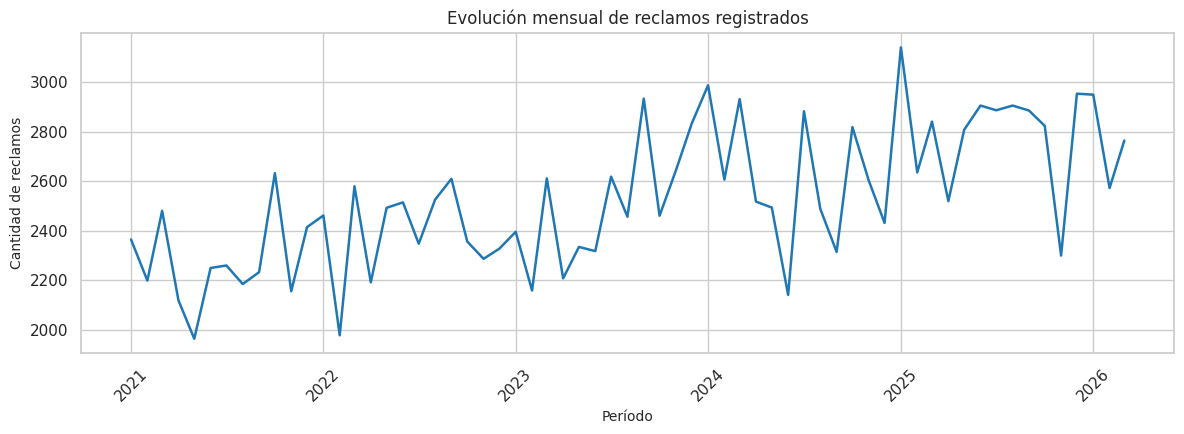

In [69]:
monthly_claims = (
    reclamos_clean.assign(periodo=reclamos_clean['fecha'].dt.to_period('M').dt.to_timestamp())
    .groupby('periodo', as_index=False)
    .size()
    .rename(columns={'size': 'cantidad_reclamos'})
)

fig, ax = plt.subplots(figsize=(12, 4.5))
sns.lineplot(data=monthly_claims, x='periodo', y='cantidad_reclamos', ax=ax, color='#1f77b4', linewidth=1.8)
ax.set_title('Evolución mensual de reclamos registrados')
ax.set_xlabel('Período')
ax.set_ylabel('Cantidad de reclamos')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

In [70]:
zone_burden = (
    zona_diario_base.groupby('zona_id', as_index=False)
    .agg(
        reclamos_totales=('reclamos_count', 'sum'),
        tiempo_operativo_total_min=('tiempo_total_operativo_min', 'sum'),
        costo_operativo_total_ars=('costo_total_compuesto_ars', 'sum'),
    )
    .sort_values(['reclamos_totales', 'tiempo_operativo_total_min'], ascending=[False, False])
)

zone_burden = apply_zone_names(zone_burden)

zone_burden[['zona_nombre'] + [c for c in zone_burden.columns if c not in {'zona_nombre', 'zona_id'}]].head(10)

,zona_nombre,reclamos_totales,tiempo_operativo_total_min,costo_operativo_total_ars
0,Montecarlo,38748.0,2.492192e+06,1.168962e+09
1,Montecarlo,29951.0,2.059467e+06,9.917715e+08
2,Montecarlo,20435.0,1.349739e+06,6.417307e+08
3,Puerto Piray,15227.0,1.238594e+06,7.104526e+08
4,El Alcazar,14174.0,1.202241e+06,7.130080e+08
5,Montecarlo,5676.0,3.932402e+05,1.905680e+08
6,Caraguatay,5387.0,4.024641e+05,2.150159e+08
7,Montecarlo,4353.0,2.922096e+05,1.404312e+08
8,Tarumá,3547.0,3.026094e+05,1.763972e+08
9,Puerto Piray,3381.0,2.702643e+05,1.471339e+08


**Interpretación.** La cobertura temporal permite observar que el problema no surge de una ventana breve o episódica, sino de una serie suficientemente extensa como para capturar estacionalidad, persistencia y cambios de intensidad operativa. A su vez, la agregación territorial muestra que la presión no está uniformemente distribuida entre zonas: un subconjunto relativamente acotado concentra gran parte de los reclamos y de la carga operativa acumulada. Esta heterogeneidad es relevante porque justifica tanto el análisis espacial como la posterior necesidad de modelos capaces de diferenciar patrones locales de demanda.

### 10.2 Distribución de variables objetivo

Antes de entrenar cualquier modelo predictivo, resulta indispensable examinar la forma empírica de las variables objetivo. La razón es simple: distribuciones muy asimétricas, con colas pesadas o fuerte concentración en valores bajos, pueden condicionar la elección de métricas, la interpretación del error y la estabilidad de los modelos. En este caso interesa analizar tres dimensiones complementarias del problema operativo: tiempo futuro de atención, costo futuro y cantidad futura de reclamos.

In [71]:
target_columns = ['y_tiempo_t+1_min', 'y_costo_t+1_ars', 'y_reclamos_t+1']

if 'target_available_t+1' in zona_diario_supervisado.columns:
    model_ready = zona_diario_supervisado.loc[zona_diario_supervisado['target_available_t+1']].copy()
else:
    model_ready = zona_diario_supervisado.dropna(subset=target_columns).copy()

model_ready_display = apply_zone_names(model_ready[target_columns + ['zona_id', 'fecha']])
model_ready_display[['zona_nombre', 'fecha'] + target_columns].head()

,zona_nombre,fecha,y_tiempo_t+1_min,y_costo_t+1_ars,y_reclamos_t+1
0,Montecarlo,2021-01-01,194.616667,91349.3275,3.0
1,Montecarlo,2021-01-02,760.116667,353667.3375,12.0
2,Montecarlo,2021-01-03,1664.250000,779101.6525,26.0
3,Montecarlo,2021-01-04,700.483333,327122.4475,11.0
4,Montecarlo,2021-01-05,1886.450000,877197.6875,30.0


In [72]:
target_stats = (
    model_ready[target_columns]
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .T
    .assign(
        q25=model_ready[target_columns].quantile(0.25),
        q75=model_ready[target_columns].quantile(0.75),
    )
    .rename_axis('target')
    .reset_index()
)

target_stats

,target,count,mean,median,std,min,max,q25,q75
0,y_tiempo_t+1_min,75451.0,151.842610,0.0,400.840638,0.0,9.339067e+03,0.0,89.266667
1,y_costo_t+1_ars,75451.0,78245.695533,0.0,201969.187097,0.0,5.383740e+06,0.0,53005.542500
2,y_reclamos_t+1,75451.0,2.106758,0.0,5.781244,0.0,1.140000e+02,0.0,1.000000


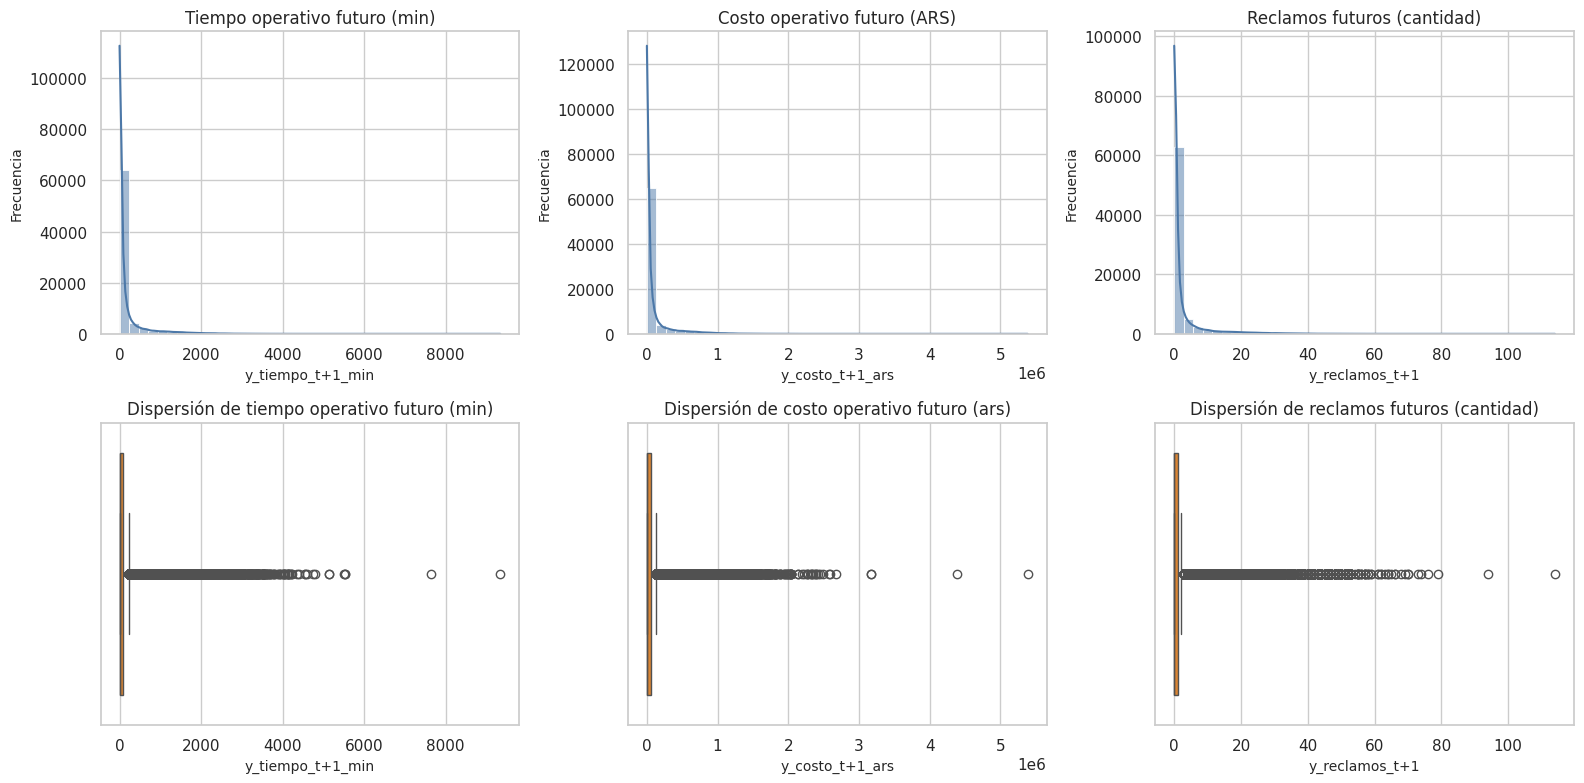

In [73]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
plot_config = [
    ('y_tiempo_t+1_min', 'Tiempo operativo futuro (min)'),
    ('y_costo_t+1_ars', 'Costo operativo futuro (ARS)'),
    ('y_reclamos_t+1', 'Reclamos futuros (cantidad)'),
]

for idx, (column, title) in enumerate(plot_config):
    sns.histplot(model_ready[column], bins=40, kde=True, ax=axes[0, idx], color='#4c78a8')
    axes[0, idx].set_title(title)
    axes[0, idx].set_xlabel(column)
    axes[0, idx].set_ylabel('Frecuencia')

    sns.boxplot(x=model_ready[column], ax=axes[1, idx], color='#f58518')
    axes[1, idx].set_title(f'Dispersión de {title.lower()}')
    axes[1, idx].set_xlabel(column)

plt.tight_layout()

**Interpretación.** La inspección de las variables objetivo permite anticipar un escenario típico de operación real: alta concentración de observaciones en niveles relativamente bajos y presencia de episodios de mayor intensidad que extienden la cola de la distribución. En términos analíticos, esto sugiere que el problema no está dominado por valores “promedio”, sino por una combinación de regularidad cotidiana y eventos de mayor carga. Para el modelado, esta estructura implica que métricas robustas y comparaciones cuidadosas contra un baseline serán especialmente importantes, ya que errores en los casos extremos pueden tener un peso operativo desproporcionado.

### 10.3 Relación entre lluvia y demanda operativa

La precipitación constituye una variable exógena de especial interés en el caso de CEML porque puede modificar simultáneamente la probabilidad de ocurrencia de fallas, la complejidad logística de la atención y la presión global sobre la operación. En términos analíticos, no se trata de asumir una relación causal automática, sino de evaluar si los días con lluvia —y en particular aquellos asociados a eventos más intensos— aparecen acompañados por mayores niveles de reclamos, tiempo operativo acumulado y costo total de atención.

Esta subsección busca, por lo tanto, identificar **asociaciones observables** entre contexto meteorológico y carga operativa. La intención es doble: enriquecer la comprensión del problema y justificar, si corresponde, la inclusión de señales de lluvia dentro de etapas posteriores de modelado.

In [74]:
rain_operational_daily = (
    zona_diario_base.groupby('fecha', as_index=False)
    .agg(
        reclamos_count=('reclamos_count', 'sum'),
        tiempo_total_operativo_min=('tiempo_total_operativo_min', 'sum'),
        costo_total_compuesto_ars=('costo_total_compuesto_ars', 'sum'),
        lluvia_mm=('lluvia_mm', 'first'),
        llovio=('llovio', 'first'),
        lluvia_intensidad=('lluvia_intensidad', 'first'),
        obs_evento_intenso_flag=('obs_evento_intenso_flag', 'first'),
        lluvia_status=('lluvia_status', 'first'),
    )
    .sort_values('fecha')
)

rain_operational_daily['lluvia_bucket'] = pd.cut(
    rain_operational_daily['lluvia_mm'].fillna(-0.1),
    bins=[-1, 0, 5, 20, float('inf')],
    labels=['sin lluvia', 'leve (0-5 mm)', 'moderada (5-20 mm)', 'alta (>20 mm)'],
    include_lowest=True,
)

rain_operational_daily['evento_lluvia'] = rain_operational_daily['llovio'].map({True: 'día lluvioso', False: 'día sin lluvia'})

rain_operational_daily.head()

,fecha,reclamos_count,tiempo_total_operativo_min,costo_total_compuesto_ars,lluvia_mm,llovio,lluvia_intensidad,obs_evento_intenso_flag,lluvia_status,lluvia_bucket,evento_lluvia
0,2021-01-01,5.0,349.800000,1.757938e+05,0.0,False,sin_lluvia,False,observed,sin lluvia,día sin lluvia
1,2021-01-02,13.0,957.950000,4.991171e+05,0.0,False,sin_lluvia,False,observed,sin lluvia,día sin lluvia
2,2021-01-03,22.0,1495.566667,7.403922e+05,0.0,False,sin_lluvia,False,observed,sin lluvia,día sin lluvia
3,2021-01-04,119.0,8861.566667,4.744680e+06,5.5,True,leve,True,observed,moderada (5-20 mm),día lluvioso
4,2021-01-05,73.0,5288.016667,2.739717e+06,45.5,True,fuerte,True,observed,alta (>20 mm),día lluvioso


In [75]:
rain_vs_dry_summary = (
    rain_operational_daily.groupby('evento_lluvia', as_index=False)
    .agg(
        dias=('fecha', 'count'),
        lluvia_media_mm=('lluvia_mm', 'mean'),
        reclamos_promedio=('reclamos_count', 'mean'),
        tiempo_operativo_promedio_min=('tiempo_total_operativo_min', 'mean'),
        costo_operativo_promedio_ars=('costo_total_compuesto_ars', 'mean'),
        reclamos_mediana=('reclamos_count', 'median'),
        tiempo_operativo_mediana_min=('tiempo_total_operativo_min', 'median'),
        costo_operativo_mediana_ars=('costo_total_compuesto_ars', 'median'),
    )
)

rain_intensity_summary = (
    rain_operational_daily.groupby('lluvia_bucket', observed=False, as_index=False)
    .agg(
        dias=('fecha', 'count'),
        reclamos_promedio=('reclamos_count', 'mean'),
        tiempo_operativo_promedio_min=('tiempo_total_operativo_min', 'mean'),
        costo_operativo_promedio_ars=('costo_total_compuesto_ars', 'mean'),
    )
)

rain_vs_dry_summary, rain_intensity_summary

(    evento_lluvia  dias  lluvia_media_mm  reclamos_promedio  \
 0    día lluvioso   575         19.50887          89.619130   
 1  día sin lluvia  1341          0.00000          80.163311   
 
    tiempo_operativo_promedio_min  costo_operativo_promedio_ars  \
 0                    6474.692870                  3.342944e+06   
 1                    5771.599205                  2.971595e+06   
 
    reclamos_mediana  tiempo_operativo_mediana_min  costo_operativo_mediana_ars  
 0              96.0                       6905.25                 3.533710e+06  
 1              90.0                       6485.10                 3.332491e+06  ,
         lluvia_bucket  dias  reclamos_promedio  tiempo_operativo_promedio_min  \
 0          sin lluvia  1341          80.163311                    5771.599205   
 1       leve (0-5 mm)   203          86.512315                    6238.983087   
 2  moderada (5-20 mm)   198          93.929293                    6772.126178   
 3       alta (>20 mm)   174

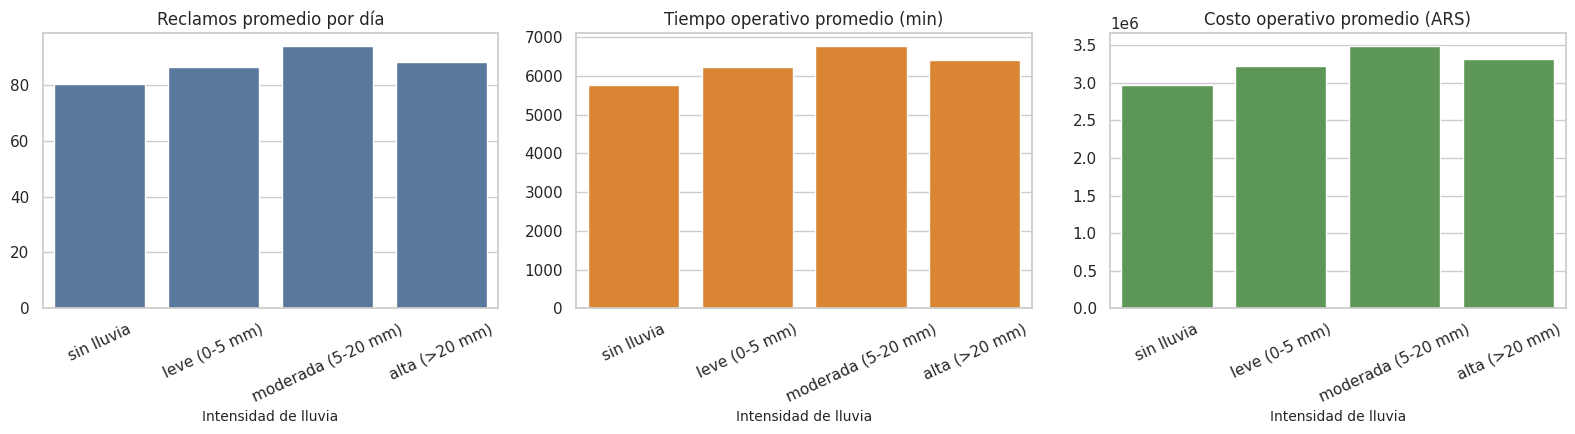

In [76]:
rain_plot_df = (
    rain_operational_daily.groupby('lluvia_bucket', observed=False, as_index=False)
    .agg(
        reclamos_promedio=('reclamos_count', 'mean'),
        tiempo_operativo_promedio_min=('tiempo_total_operativo_min', 'mean'),
        costo_operativo_promedio_ars=('costo_total_compuesto_ars', 'mean'),
    )
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=False)
metrics = [
    ('reclamos_promedio', 'Reclamos promedio por día', '#4c78a8'),
    ('tiempo_operativo_promedio_min', 'Tiempo operativo promedio (min)', '#f58518'),
    ('costo_operativo_promedio_ars', 'Costo operativo promedio (ARS)', '#54a24b'),
]

for ax, (metric, title, color) in zip(axes, metrics):
    sns.barplot(data=rain_plot_df, x='lluvia_bucket', y=metric, ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel('Intensidad de lluvia')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=25)

plt.tight_layout()

,obs_evento_intenso_flag,dias,lluvia_media_mm,reclamos_promedio,tiempo_operativo_promedio_min,costo_operativo_promedio_ars
0,sin marca de evento intenso,1454,3.539477,80.990371,5827.089775,2.998720e+06
1,con marca de evento intenso,462,13.141126,89.329004,6472.022511,3.348406e+06


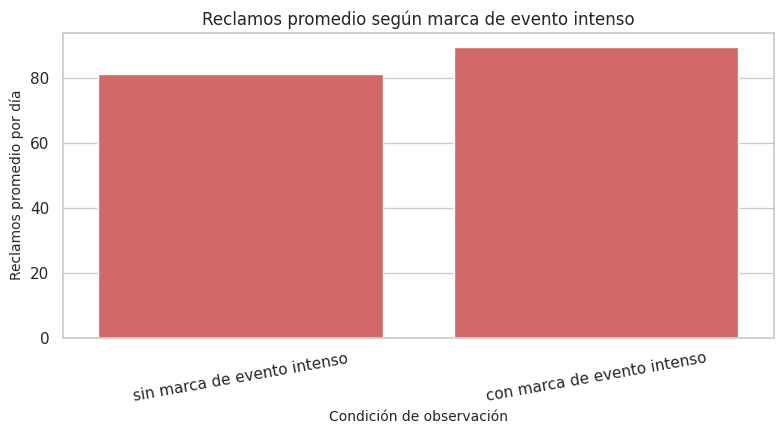

In [77]:
intense_event_summary = (
    rain_operational_daily.groupby('obs_evento_intenso_flag', as_index=False)
    .agg(
        dias=('fecha', 'count'),
        lluvia_media_mm=('lluvia_mm', 'mean'),
        reclamos_promedio=('reclamos_count', 'mean'),
        tiempo_operativo_promedio_min=('tiempo_total_operativo_min', 'mean'),
        costo_operativo_promedio_ars=('costo_total_compuesto_ars', 'mean'),
    )
    .replace({'obs_evento_intenso_flag': {True: 'con marca de evento intenso', False: 'sin marca de evento intenso'}})
)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(
    data=intense_event_summary,
    x='obs_evento_intenso_flag',
    y='reclamos_promedio',
    ax=ax,
    color='#e45756'
)
ax.set_title('Reclamos promedio según marca de evento intenso')
ax.set_xlabel('Condición de observación')
ax.set_ylabel('Reclamos promedio por día')
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()

intense_event_summary

In [78]:
rain_correlation = rain_operational_daily[[
    'lluvia_mm',
    'reclamos_count',
    'tiempo_total_operativo_min',
    'costo_total_compuesto_ars',
]].corr(method='spearman').round(3)

rain_correlation

,lluvia_mm,reclamos_count,tiempo_total_operativo_min,costo_total_compuesto_ars
lluvia_mm,1.000,0.094,0.096,0.098
reclamos_count,0.094,1.000,0.999,0.996
tiempo_total_operativo_min,0.096,0.999,1.000,0.999
costo_total_compuesto_ars,0.098,0.996,0.999,1.000


**Interpretación.** La evidencia presentada sugiere que la lluvia funciona como un contexto operativo relevante, en el sentido de que los días lluviosos —y especialmente aquellos asociados a mayor intensidad o a marcas de evento intenso— pueden coincidir con una presión superior sobre reclamos, tiempo acumulado de atención y costo operativo. Sin embargo, esta lectura debe formularse con cautela: la asociación observada no implica por sí misma causalidad, y además puede estar modulada por factores no incluidos en esta subsección, como estacionalidad, composición territorial de la demanda o recurrencia diferencial entre zonas.

En consecuencia, la lluvia debe entenderse aquí como una **señal explicativa plausible y defendible**, útil para contextualizar la operación y potencialmente valiosa para modelado, pero no como una explicación autosuficiente del comportamiento operativo.

### 10.4 Heterogeneidad espacial entre zonas

La dimensión espacial es central para el problema de priorización porque la presión operativa no se distribuye homogéneamente en el territorio. Si determinadas zonas concentran de manera persistente mayor volumen de reclamos, mayor tiempo de atención o mayor costo acumulado, entonces la inversión en infraestructura no debería decidirse con criterios uniformes, sino atendiendo a esa heterogeneidad.

En consecuencia, esta subsección busca identificar si la carga operacional está concentrada en un subconjunto de zonas o si, por el contrario, se reparte de manera relativamente dispersa. Esta distinción es importante porque cambia la lógica de intervención: una estructura concentrada favorece estrategias focalizadas, mientras que una estructura más difusa exigiría respuestas de alcance territorial más amplio.

In [79]:
zona_cluster_resumen = pd.read_parquet(ROOT / 'data/processed/zona_cluster_resumen.parquet')

zone_context = (
    zona_diario_base.groupby('zona_id', as_index=False)
    .agg(
        zona_localidad_principal=('zona_localidad_principal', 'first'),
        destinos_count=('zona_destinos_count', 'first'),
        centroid_lat=('centroid_lat', 'first'),
        centroid_lon=('centroid_lon', 'first'),
        diameter_km=('zona_diameter_km', 'first'),
    )
)

zone_operational_summary = (
    zona_diario_base.groupby('zona_id', as_index=False)
    .agg(
        reclamos_totales=('reclamos_count', 'sum'),
        tiempo_operativo_total_min=('tiempo_total_operativo_min', 'sum'),
        costo_operativo_total_ars=('costo_total_compuesto_ars', 'sum'),
        dias_observados=('fecha', 'nunique'),
        lluvia_media_mm=('lluvia_mm', 'mean'),
    )
    .merge(zone_context, on='zona_id', how='left')
    .merge(
        zona_cluster_resumen[['zona_id', 'reclamos_count']].rename(columns={'reclamos_count': 'reclamos_historicos_cluster'}),
        on='zona_id', how='left'
    )
)

zone_operational_summary['rank_reclamos'] = zone_operational_summary['reclamos_totales'].rank(method='dense', ascending=False)
zone_operational_summary['rank_tiempo'] = zone_operational_summary['tiempo_operativo_total_min'].rank(method='dense', ascending=False)
zone_operational_summary['rank_costo'] = zone_operational_summary['costo_operativo_total_ars'].rank(method='dense', ascending=False)
zone_operational_summary['score_priorizacion'] = (
    zone_operational_summary['rank_reclamos'] +
    zone_operational_summary['rank_tiempo'] +
    zone_operational_summary['rank_costo']
)

zone_operational_summary['participacion_reclamos'] = zone_operational_summary['reclamos_totales'] / zone_operational_summary['reclamos_totales'].sum()
zone_operational_summary['participacion_costo'] = zone_operational_summary['costo_operativo_total_ars'] / zone_operational_summary['costo_operativo_total_ars'].sum()
zone_operational_summary['participacion_tiempo'] = zone_operational_summary['tiempo_operativo_total_min'] / zone_operational_summary['tiempo_operativo_total_min'].sum()
zone_operational_summary['participacion_promedio'] = zone_operational_summary[['participacion_reclamos', 'participacion_costo', 'participacion_tiempo']].mean(axis=1)
zone_operational_summary['distancia_media_proxy_km'] = zone_operational_summary['diameter_km'] / 2
zone_operational_summary['cuartil_distancia'] = pd.qcut(
    zone_operational_summary['diameter_km'].rank(method='first'),
    q=4,
    labels=['Q1 más cercanas', 'Q2 cercanas-intermedias', 'Q3 lejanas-intermedias', 'Q4 más lejanas']
)

zone_operational_summary = apply_zone_names(zone_operational_summary)
zone_operational_summary = zone_operational_summary[['zona_nombre'] + [c for c in zone_operational_summary.columns if c != 'zona_nombre']]

zone_operational_summary[['zona_nombre'] + [c for c in zone_operational_summary.columns if c not in {'zona_nombre', 'zona_id'}]].head()

,zona_nombre,reclamos_totales,tiempo_operativo_total_min,costo_operativo_total_ars,dias_observados,lluvia_media_mm,zona_localidad_principal,destinos_count,centroid_lat,centroid_lon,...,rank_reclamos,rank_tiempo,rank_costo,score_priorizacion,participacion_reclamos,participacion_costo,participacion_tiempo,participacion_promedio,distancia_media_proxy_km,cuartil_distancia
0,Montecarlo,38748.0,2.492192e+06,1.168962e+09,1916,5.854697,MONTECARLO,2897,-26.567067,-54.756846,...,1.0,1.0,1.0,3.0,0.243652,0.197891,0.217418,0.219654,2.4509,Q4 más lejanas
1,Montecarlo,29951.0,2.059467e+06,9.917715e+08,1916,5.854697,MONTECARLO,2459,-26.567719,-54.774326,...,2.0,2.0,2.0,6.0,0.188336,0.167895,0.179667,0.178633,1.8457,Q2 cercanas-intermedias
2,Montecarlo,20435.0,1.349739e+06,6.417307e+08,1915,5.857755,MONTECARLO,1529,-26.576653,-54.736634,...,3.0,3.0,5.0,11.0,0.128498,0.108637,0.117751,0.118295,2.4897,Q4 más lejanas
3,Puerto Piray,15227.0,1.238594e+06,7.104526e+08,1916,5.854697,PUERTO PIRAY,2486,-26.469557,-54.707538,...,4.0,4.0,4.0,12.0,0.095749,0.120271,0.108055,0.108025,2.1836,Q2 cercanas-intermedias
4,El Alcazar,14174.0,1.202241e+06,7.130080e+08,1915,5.857755,MONTECARLO,1189,-26.714605,-54.813441,...,5.0,5.0,3.0,13.0,0.089128,0.120704,0.104883,0.104905,2.1541,Q2 cercanas-intermedias


In [80]:
top_zones_claims = (
    zone_operational_summary[['zona_nombre', 'reclamos_totales', 'dias_observados', 'destinos_count', 'diameter_km']]
    .sort_values('reclamos_totales', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_zones_claims

,zona_nombre,reclamos_totales,dias_observados,destinos_count,diameter_km
0,Montecarlo,38748.0,1916,2897,4.9018
1,Montecarlo,29951.0,1916,2459,3.6914
2,Montecarlo,20435.0,1915,1529,4.9794
3,Puerto Piray,15227.0,1916,2486,4.3672
4,El Alcazar,14174.0,1915,1189,4.3082
5,Montecarlo,5676.0,1913,595,4.7636
6,Caraguatay,5387.0,1913,453,4.9615
7,Montecarlo,4353.0,1916,559,3.6108
8,Tarumá,3547.0,1915,288,4.6265
9,Puerto Piray,3381.0,1915,344,4.4014


In [81]:
top_zones_cost = (
    zone_operational_summary[['zona_nombre', 'costo_operativo_total_ars', 'reclamos_totales', 'tiempo_operativo_total_min']]
    .sort_values('costo_operativo_total_ars', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_zones_cost

,zona_nombre,costo_operativo_total_ars,reclamos_totales,tiempo_operativo_total_min
0,Montecarlo,1.168962e+09,38748.0,2.492192e+06
1,Montecarlo,9.917715e+08,29951.0,2.059467e+06
2,El Alcazar,7.130080e+08,14174.0,1.202241e+06
3,Puerto Piray,7.104526e+08,15227.0,1.238594e+06
4,Montecarlo,6.417307e+08,20435.0,1.349739e+06
5,Caraguatay,2.150159e+08,5387.0,4.024641e+05
6,Montecarlo,1.905680e+08,5676.0,3.932402e+05
7,Tarumá,1.763972e+08,3547.0,3.026094e+05
8,Puerto Piray,1.471339e+08,3381.0,2.702643e+05
9,Montecarlo,1.404312e+08,4353.0,2.922096e+05


In [82]:
top_zones_time = (
    zone_operational_summary[['zona_nombre', 'tiempo_operativo_total_min', 'reclamos_totales', 'costo_operativo_total_ars']]
    .sort_values('tiempo_operativo_total_min', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_zones_time

,zona_nombre,tiempo_operativo_total_min,reclamos_totales,costo_operativo_total_ars
0,Montecarlo,2.492192e+06,38748.0,1.168962e+09
1,Montecarlo,2.059467e+06,29951.0,9.917715e+08
2,Montecarlo,1.349739e+06,20435.0,6.417307e+08
3,Puerto Piray,1.238594e+06,15227.0,7.104526e+08
4,El Alcazar,1.202241e+06,14174.0,7.130080e+08
5,Caraguatay,4.024641e+05,5387.0,2.150159e+08
6,Montecarlo,3.932402e+05,5676.0,1.905680e+08
7,Tarumá,3.026094e+05,3547.0,1.763972e+08
8,Montecarlo,2.922096e+05,4353.0,1.404312e+08
9,Puerto Piray,2.702643e+05,3381.0,1.471339e+08


In [83]:
zone_priority_ranking = (
    zone_operational_summary[[
        'zona_nombre',
        'reclamos_totales',
        'tiempo_operativo_total_min',
        'costo_operativo_total_ars',
        'rank_reclamos',
        'rank_tiempo',
        'rank_costo',
        'score_priorizacion',
        'destinos_count',
        'diameter_km',
    ]]
    .sort_values(['score_priorizacion', 'costo_operativo_total_ars', 'tiempo_operativo_total_min'], ascending=[True, False, False])
    .head(15)
    .reset_index(drop=True)
)

zone_priority_ranking

,zona_nombre,reclamos_totales,tiempo_operativo_total_min,costo_operativo_total_ars,rank_reclamos,rank_tiempo,rank_costo,score_priorizacion,destinos_count,diameter_km
0,Montecarlo,38748.0,2.492192e+06,1.168962e+09,1.0,1.0,1.0,3.0,2897,4.9018
1,Montecarlo,29951.0,2.059467e+06,9.917715e+08,2.0,2.0,2.0,6.0,2459,3.6914
2,Montecarlo,20435.0,1.349739e+06,6.417307e+08,3.0,3.0,5.0,11.0,1529,4.9794
3,Puerto Piray,15227.0,1.238594e+06,7.104526e+08,4.0,4.0,4.0,12.0,2486,4.3672
4,El Alcazar,14174.0,1.202241e+06,7.130080e+08,5.0,5.0,3.0,13.0,1189,4.3082
5,Caraguatay,5387.0,4.024641e+05,2.150159e+08,7.0,6.0,6.0,19.0,453,4.9615
6,Montecarlo,5676.0,3.932402e+05,1.905680e+08,6.0,7.0,7.0,20.0,595,4.7636
7,Tarumá,3547.0,3.026094e+05,1.763972e+08,9.0,8.0,8.0,25.0,288,4.6265
8,Montecarlo,4353.0,2.922096e+05,1.404312e+08,8.0,9.0,10.0,27.0,559,3.6108
9,Puerto Piray,3381.0,2.702643e+05,1.471339e+08,10.0,10.0,9.0,29.0,344,4.4014


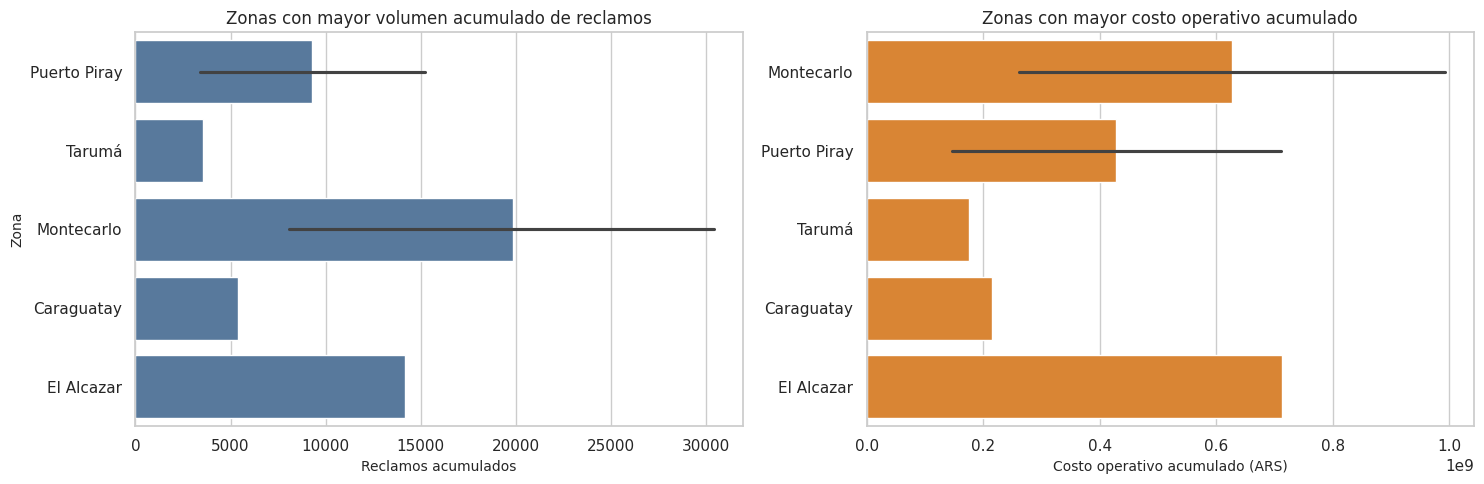

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top_claims_plot = top_zones_claims.sort_values('reclamos_totales', ascending=True)
sns.barplot(data=top_claims_plot, x='reclamos_totales', y='zona_nombre', ax=axes[0], color='#4c78a8')
axes[0].set_title('Zonas con mayor volumen acumulado de reclamos')
axes[0].set_xlabel('Reclamos acumulados')
axes[0].set_ylabel('Zona')

top_cost_plot = top_zones_cost.sort_values('costo_operativo_total_ars', ascending=True)
sns.barplot(data=top_cost_plot, x='costo_operativo_total_ars', y='zona_nombre', ax=axes[1], color='#f58518')
axes[1].set_title('Zonas con mayor costo operativo acumulado')
axes[1].set_xlabel('Costo operativo acumulado (ARS)')
axes[1].set_ylabel('')

plt.tight_layout()

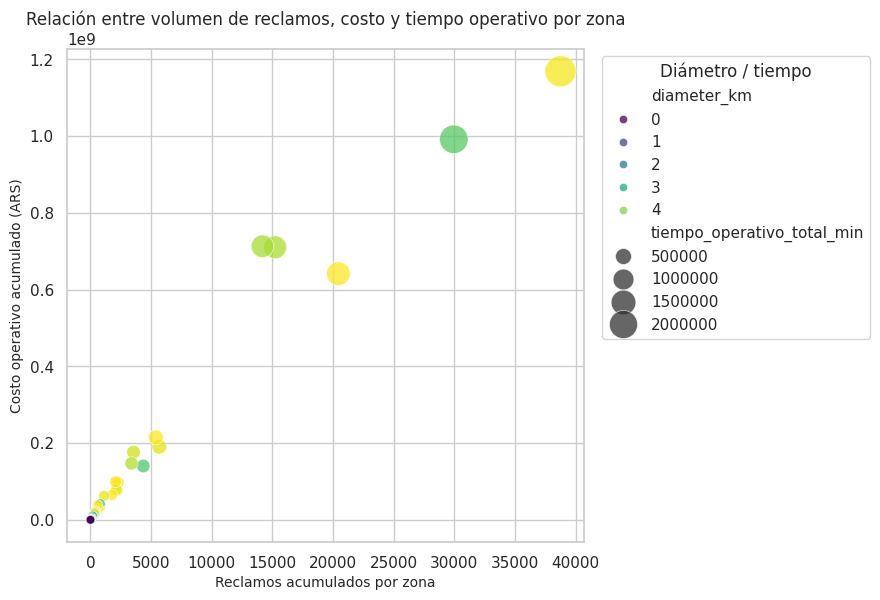

In [85]:
scatter_df = zone_operational_summary.copy()

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=scatter_df,
    x='reclamos_totales',
    y='costo_operativo_total_ars',
    size='tiempo_operativo_total_min',
    sizes=(40, 500),
    hue='diameter_km',
    palette='viridis',
    alpha=0.75,
    ax=ax,
)
ax.set_title('Relación entre volumen de reclamos, costo y tiempo operativo por zona')
ax.set_xlabel('Reclamos acumulados por zona')
ax.set_ylabel('Costo operativo acumulado (ARS)')
ax.legend(title='Diámetro / tiempo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

In [86]:
zone_centroid_summary = (
    zone_operational_summary[[
        'zona_nombre', 'zona_localidad_principal', 'centroid_lat', 'centroid_lon',
        'reclamos_totales', 'tiempo_operativo_total_min', 'costo_operativo_total_ars',
        'diameter_km', 'distancia_media_proxy_km', 'score_priorizacion'
    ]]
    .sort_values('costo_operativo_total_ars', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

zone_centroid_summary

,zona_nombre,zona_localidad_principal,centroid_lat,centroid_lon,reclamos_totales,tiempo_operativo_total_min,costo_operativo_total_ars,diameter_km,distancia_media_proxy_km,score_priorizacion
0,Montecarlo,MONTECARLO,-26.567067,-54.756846,38748.0,2.492192e+06,1.168962e+09,4.9018,2.45090,3.0
1,Montecarlo,MONTECARLO,-26.567719,-54.774326,29951.0,2.059467e+06,9.917715e+08,3.6914,1.84570,6.0
2,El Alcazar,MONTECARLO,-26.714605,-54.813441,14174.0,1.202241e+06,7.130080e+08,4.3082,2.15410,13.0
3,Puerto Piray,PUERTO PIRAY,-26.469557,-54.707538,15227.0,1.238594e+06,7.104526e+08,4.3672,2.18360,12.0
4,Montecarlo,MONTECARLO,-26.576653,-54.736634,20435.0,1.349739e+06,6.417307e+08,4.9794,2.48970,11.0
5,Caraguatay,MONTECARLO,-26.647737,-54.745580,5387.0,4.024641e+05,2.150159e+08,4.9615,2.48075,19.0
6,Montecarlo,MONTECARLO,-26.553842,-54.754354,5676.0,3.932402e+05,1.905680e+08,4.7636,2.38180,20.0
7,Tarumá,MONTECARLO,-26.720035,-54.719408,3547.0,3.026094e+05,1.763972e+08,4.6265,2.31325,25.0
8,Puerto Piray,MONTECARLO,-26.540350,-54.657110,3381.0,2.702643e+05,1.471339e+08,4.4014,2.20070,29.0
9,Montecarlo,MONTECARLO,-26.573813,-54.725982,4353.0,2.922096e+05,1.404312e+08,3.6108,1.80540,27.0


**Evidencia cartográfica de centroides.** Para facilitar una lectura territorial más intuitiva, se incorporan mapas interactivos Folium basados en centroides de zona. Aunque no reemplazan un análisis geoespacial detallado, estos mapas permiten ubicar con claridad dónde se concentran el volumen de reclamos, el costo operativo, la exigencia territorial y el score de priorización. La combinación de cartografía base, centroides y ventanas emergentes permite vincular la lectura estadística con una representación espacial más cercana al uso decisional.

In [87]:
def _scale_value(value, min_value, max_value, out_min=5, out_max=18):
    if pd.isna(value):
        return out_min
    if min_value == max_value:
        return (out_min + out_max) / 2
    return out_min + (float(value - min_value) / float(max_value - min_value)) * (out_max - out_min)


def build_zone_folium_map(data, metric, title, popup_metric_label, color_mode='continuous', reverse=False):
    map_df = apply_zone_names(data).dropna(subset=['centroid_lat', 'centroid_lon']).copy()
    center_lat = float(map_df['centroid_lat'].mean())
    center_lon = float(map_df['centroid_lon'].mean())

    fmap = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=10,
        tiles='OpenStreetMap',
        control_scale=True,
    )

    cluster_layer = MarkerCluster(
        name=title,
        options={
            'disableClusteringAtZoom': 11,
            'showCoverageOnHover': False,
            'spiderfyOnMaxZoom': True,
        },
    ).add_to(fmap)

    if color_mode == 'continuous':
        value_min = float(map_df[metric].min())
        value_max = float(map_df[metric].max())
        palette = ['#dbeafe', '#93c5fd', '#60a5fa', '#2563eb', '#1d4ed8'] if not reverse else ['#fee2e2', '#fca5a5', '#f87171', '#dc2626', '#991b1b']

        def color_func(v):
            if value_min == value_max:
                return palette[-1]
            norm = float(v - value_min) / float(value_max - value_min)
            idx = min(int(norm * len(palette)), len(palette) - 1)
            return palette[idx]

        sort_metric = metric
    else:
        category_colors = {
            'Q1 más cercanas': '#93c5fd',
            'Q2 cercanas-intermedias': '#60a5fa',
            'Q3 lejanas-intermedias': '#f59e0b',
            'Q4 más lejanas': '#dc2626',
        }
        color_func = lambda v: category_colors.get(v, '#6b7280')
        sort_metric = 'costo_operativo_total_ars'
        value_min = float(map_df['costo_operativo_total_ars'].min())
        value_max = float(map_df['costo_operativo_total_ars'].max())

    bounds = []
    for _, row in map_df.sort_values(sort_metric, ascending=False).iterrows():
        lat = float(row['centroid_lat'])
        lon = float(row['centroid_lon'])
        marker_size_ref = row['costo_operativo_total_ars'] if color_mode == 'categorical' else row[metric]
        radius = _scale_value(marker_size_ref, value_min, value_max, 6, 20)
        locality = row.get('zona_localidad_principal', 's/d')
        zone_name = row.get('zona_nombre', row.get('zona_id', 's/d'))
        popup_html = f"""
        <div style='min-width: 240px;'>
            <strong>{zone_name}</strong><br>
            Localidad principal: {locality}<br>
            Reclamos acumulados: {int(row['reclamos_totales']):,}<br>
            Costo operativo total: ARS {row['costo_operativo_total_ars']:,.0f}<br>
            Tiempo operativo total: {row['tiempo_operativo_total_min']:,.0f} min<br>
            Diámetro zona: {row['diameter_km']:.2f} km<br>
            Distancia proxy: {row['distancia_media_proxy_km']:.2f} km<br>
            {popup_metric_label}: {row[metric]}
        </div>
        """.strip()
        tooltip = f"{zone_name}"

        folium.CircleMarker(
            location=[lat, lon],
            radius=radius,
            color='#1f2937',
            weight=1,
            fill=True,
            fill_color=color_func(row[metric]),
            fill_opacity=0.80,
            tooltip=tooltip,
            popup=folium.Popup(popup_html, max_width=300),
        ).add_to(cluster_layer)
        bounds.append([lat, lon])

    if bounds:
        fmap.fit_bounds(bounds, padding=(20, 20))

    folium.LayerControl(collapsed=False).add_to(fmap)
    return fmap

In [88]:
build_zone_folium_map(
    zone_operational_summary,
    metric='reclamos_totales',
    title='Reclamos totales por zona',
    popup_metric_label='Reclamos acumulados',
    color_mode='continuous'
)

In [89]:
build_zone_folium_map(
    zone_operational_summary,
    metric='costo_operativo_total_ars',
    title='Costo operativo total por zona',
    popup_metric_label='Costo operativo total',
    color_mode='continuous'
)

In [90]:
build_zone_folium_map(
    zone_operational_summary,
    metric='cuartil_distancia',
    title='Exigencia territorial por cuartil de distancia',
    popup_metric_label='Cuartil de distancia',
    color_mode='categorical'
)

In [91]:
zone_priority_map = zone_operational_summary.copy()
zone_priority_map['score_prioridad_visual'] = zone_priority_map['score_priorizacion'].max() - zone_priority_map['score_priorizacion']

build_zone_folium_map(
    zone_priority_map,
    metric='score_prioridad_visual',
    title='Score de priorización por zona',
    popup_metric_label='Score de prioridad visual',
    color_mode='continuous',
    reverse=True,
)

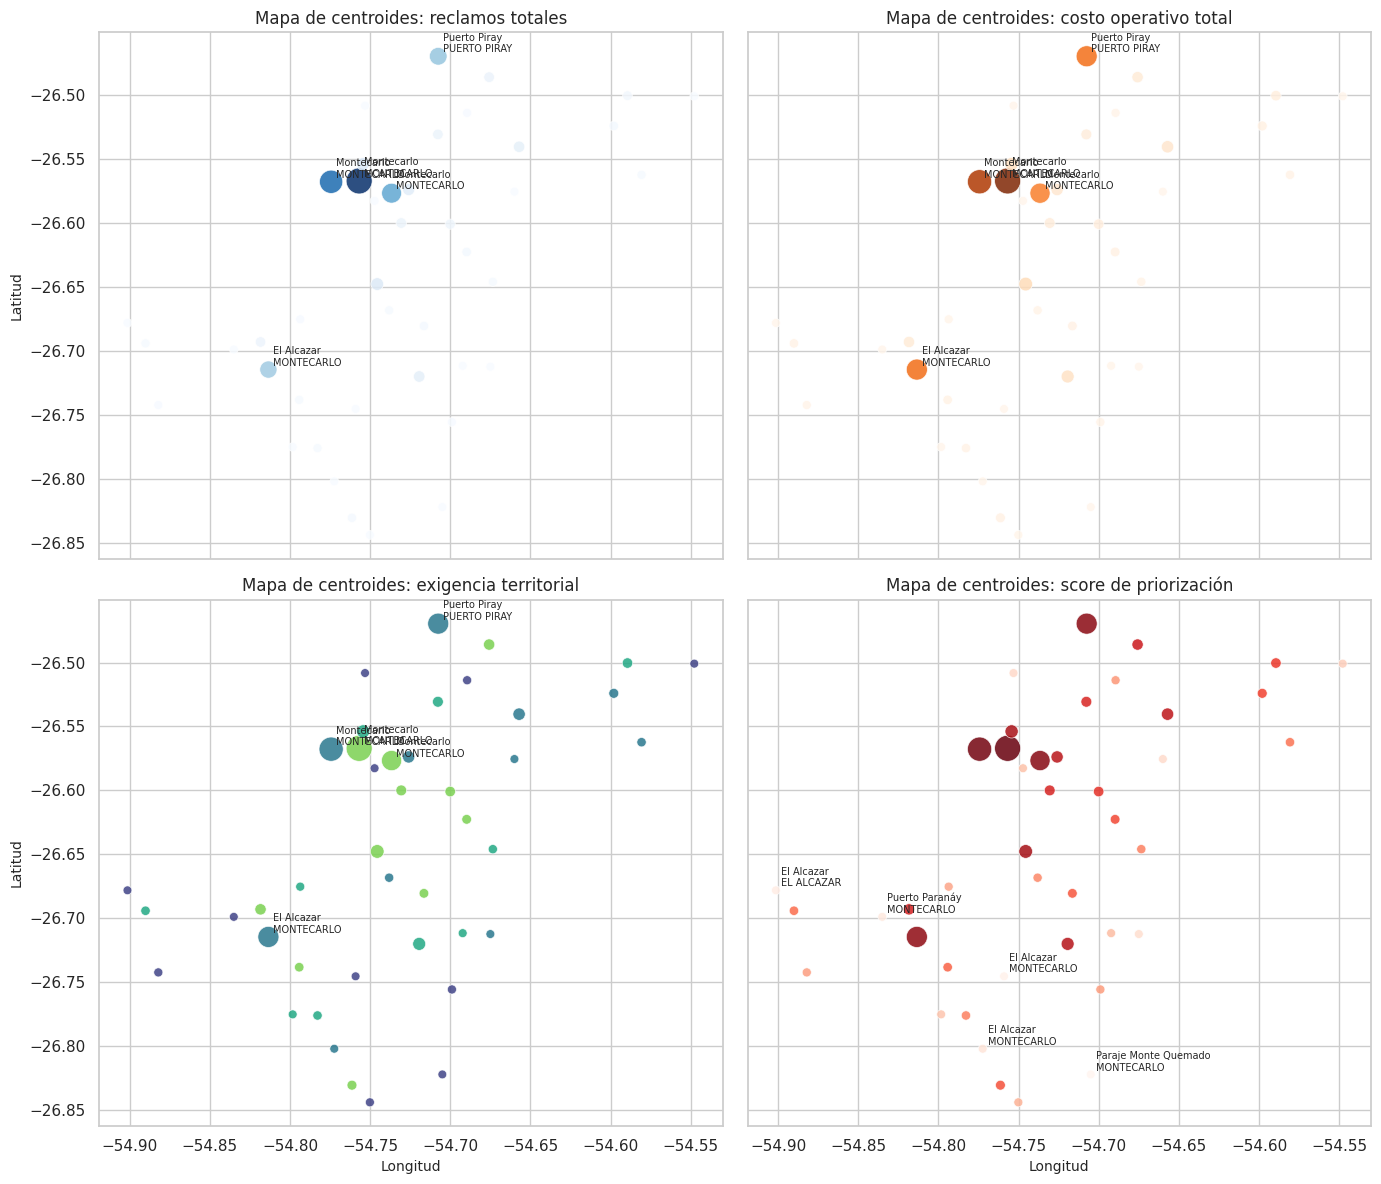

In [92]:
map_df = zone_operational_summary.copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharex=True, sharey=True)
map_specs = [
    ('reclamos_totales', 'Mapa de centroides: reclamos totales', 'Blues'),
    ('costo_operativo_total_ars', 'Mapa de centroides: costo operativo total', 'Oranges'),
    ('cuartil_distancia', 'Mapa de centroides: exigencia territorial', 'viridis'),
    ('score_priorizacion', 'Mapa de centroides: score de priorización', 'Reds_r'),
]

for ax, (metric, title, palette) in zip(axes.flatten(), map_specs):
    if metric == 'cuartil_distancia':
        sns.scatterplot(
            data=map_df,
            x='centroid_lon', y='centroid_lat',
            hue=metric, size='costo_operativo_total_ars', sizes=(40, 350),
            palette=palette, alpha=0.85, ax=ax, legend=False
        )
    else:
        sns.scatterplot(
            data=map_df,
            x='centroid_lon', y='centroid_lat',
            hue=metric, size=metric if metric != 'score_priorizacion' else 'costo_operativo_total_ars',
            sizes=(40, 350), palette=palette, alpha=0.85, ax=ax, legend=False
        )
    top_labels = map_df.sort_values(metric if metric != 'cuartil_distancia' else 'costo_operativo_total_ars', ascending=False).head(5)
    for _, row in top_labels.iterrows():
        ax.text(row['centroid_lon'] + 0.003, row['centroid_lat'] + 0.003, f"{row['zona_nombre']}\n{row['zona_localidad_principal']}", fontsize=7)
    ax.set_title(title)
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')

plt.tight_layout()

In [93]:
zone_participation_detail = (
    zone_operational_summary[[
        'zona_nombre', 'zona_localidad_principal', 'reclamos_totales', 'costo_operativo_total_ars',
        'tiempo_operativo_total_min', 'participacion_reclamos', 'participacion_costo',
        'participacion_tiempo', 'participacion_promedio', 'score_priorizacion'
    ]]
    .sort_values(['participacion_promedio', 'costo_operativo_total_ars'], ascending=[False, False])
    .reset_index(drop=True)
)

zone_participation_detail['participacion_reclamos_acum'] = zone_participation_detail['participacion_reclamos'].cumsum()
zone_participation_detail['participacion_costo_acum'] = zone_participation_detail['participacion_costo'].cumsum()
zone_participation_detail['participacion_tiempo_acum'] = zone_participation_detail['participacion_tiempo'].cumsum()

zone_participation_detail.head(15)

,zona_nombre,zona_localidad_principal,reclamos_totales,costo_operativo_total_ars,tiempo_operativo_total_min,participacion_reclamos,participacion_costo,participacion_tiempo,participacion_promedio,score_priorizacion,participacion_reclamos_acum,participacion_costo_acum,participacion_tiempo_acum
0,Montecarlo,MONTECARLO,38748.0,1.168962e+09,2.492192e+06,0.243652,0.197891,0.217418,0.219654,3.0,0.243652,0.197891,0.217418
1,Montecarlo,MONTECARLO,29951.0,9.917715e+08,2.059467e+06,0.188336,0.167895,0.179667,0.178633,6.0,0.431988,0.365786,0.397086
2,Montecarlo,MONTECARLO,20435.0,6.417307e+08,1.349739e+06,0.128498,0.108637,0.117751,0.118295,11.0,0.560485,0.474423,0.514837
3,Puerto Piray,PUERTO PIRAY,15227.0,7.104526e+08,1.238594e+06,0.095749,0.120271,0.108055,0.108025,12.0,0.656235,0.594694,0.622891
4,El Alcazar,MONTECARLO,14174.0,7.130080e+08,1.202241e+06,0.089128,0.120704,0.104883,0.104905,13.0,0.745363,0.715397,0.727774
5,Caraguatay,MONTECARLO,5387.0,2.150159e+08,4.024641e+05,0.033874,0.036400,0.035111,0.035128,19.0,0.779237,0.751797,0.762885
6,Montecarlo,MONTECARLO,5676.0,1.905680e+08,3.932402e+05,0.035691,0.032261,0.034306,0.034086,20.0,0.814928,0.784058,0.797192
7,Tarumá,MONTECARLO,3547.0,1.763972e+08,3.026094e+05,0.022304,0.029862,0.026400,0.026188,25.0,0.837232,0.813920,0.823591
8,Montecarlo,MONTECARLO,4353.0,1.404312e+08,2.922096e+05,0.027372,0.023773,0.025492,0.025546,27.0,0.864604,0.837693,0.849083
9,Puerto Piray,MONTECARLO,3381.0,1.471339e+08,2.702643e+05,0.021260,0.024908,0.023578,0.023249,29.0,0.885864,0.862601,0.872661


**Participación por zona.** Más allá de los agrupamientos territoriales, resulta útil observar la contribución específica de cada zona al total del sistema. Esta vista permite identificar qué territorios explican la mayor parte de los reclamos, del costo y del tiempo acumulado, y facilita una lectura tipo Pareto orientada a priorización.

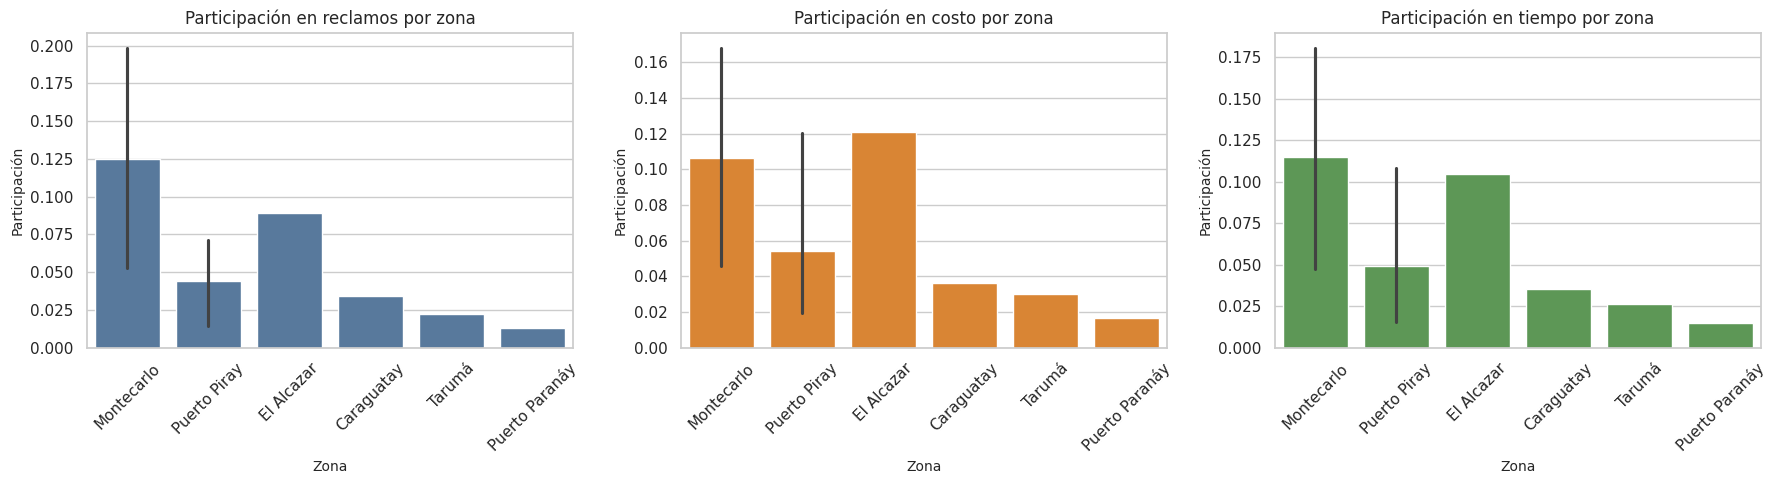

In [94]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_base = zone_participation_detail.head(12).copy()

sns.barplot(data=plot_base, x='zona_nombre', y='participacion_reclamos', ax=axes[0], color='#4c78a8')
axes[0].set_title('Participación en reclamos por zona')
axes[0].set_xlabel('Zona')
axes[0].set_ylabel('Participación')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=plot_base, x='zona_nombre', y='participacion_costo', ax=axes[1], color='#f58518')
axes[1].set_title('Participación en costo por zona')
axes[1].set_xlabel('Zona')
axes[1].set_ylabel('Participación')
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(data=plot_base, x='zona_nombre', y='participacion_tiempo', ax=axes[2], color='#54a24b')
axes[2].set_title('Participación en tiempo por zona')
axes[2].set_xlabel('Zona')
axes[2].set_ylabel('Participación')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()

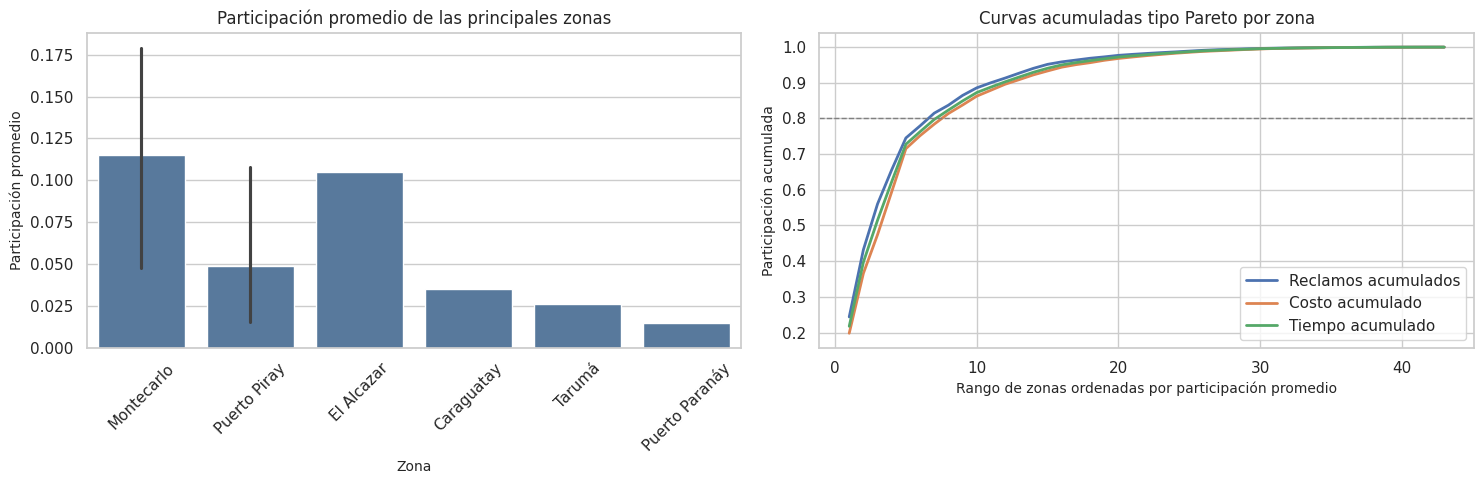

In [95]:
pareto_df = zone_participation_detail.copy()
pareto_df['rank'] = range(1, len(pareto_df) + 1)
pareto_df['cumulative_reclamos'] = pareto_df['participacion_reclamos'].cumsum()
pareto_df['cumulative_costo'] = pareto_df['participacion_costo'].cumsum()
pareto_df['cumulative_tiempo'] = pareto_df['participacion_tiempo'].cumsum()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=pareto_df.head(12), x='zona_nombre', y='participacion_promedio', ax=axes[0], color='#4c78a8')
axes[0].set_title('Participación promedio de las principales zonas')
axes[0].set_xlabel('Zona')
axes[0].set_ylabel('Participación promedio')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(pareto_df['rank'], pareto_df['cumulative_reclamos'], label='Reclamos acumulados', linewidth=2)
axes[1].plot(pareto_df['rank'], pareto_df['cumulative_costo'], label='Costo acumulado', linewidth=2)
axes[1].plot(pareto_df['rank'], pareto_df['cumulative_tiempo'], label='Tiempo acumulado', linewidth=2)
axes[1].axhline(0.8, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Curvas acumuladas tipo Pareto por zona')
axes[1].set_xlabel('Rango de zonas ordenadas por participación promedio')
axes[1].set_ylabel('Participación acumulada')
axes[1].legend()

plt.tight_layout()

**Interpretación cartográfica y de participación.** Los mapas Folium permiten apreciar con mayor claridad que la carga territorial no se organiza de manera homogénea: ciertos centroides sobresalen de forma consistente cuando se observan reclamos, costo, exigencia espacial y score de priorización. La ventaja de esta representación es que traduce la evidencia cuantitativa a una lógica territorial inmediatamente interpretable, aproximando la lectura analítica a una lógica de decisión sobre el territorio real.

Las tablas y gráficos de participación por zona refuerzan esa misma conclusión desde otra perspectiva. Si un número reducido de zonas concentra una fracción alta de reclamos, costo y tiempo acumulado, entonces la priorización focalizada no es solo una intuición razonable, sino una consecuencia directa de la estructura observada. En otras palabras, la evidencia espacial y la evidencia de participación convergen para señalar que la mayor carga del sistema se explica por pocos nodos territoriales dominantes.

**Interpretación.** La comparación entre zonas permite evaluar si la carga operacional relevante para la toma de decisiones está concentrada o dispersa. Si los rankings por reclamos, tiempo y costo muestran una superposición importante entre las primeras posiciones, ello sugiere que existe un subconjunto de zonas con presión estructuralmente superior al resto del territorio. En términos de gestión, este hallazgo fortalece la lógica de priorización focalizada: allí donde coinciden volumen, costo y tiempo acumulado, la infraestructura presenta una mayor probabilidad de generar retornos operativos si se interviene con criterio estratégico.

No obstante, esta lectura también debe matizarse. Una zona de alto costo no necesariamente expresa la misma problemática que una zona de alto volumen, y parte de la diferencia puede deberse a distancias, dispersión geográfica o composición del tipo de reclamos. Por lo tanto, la heterogeneidad espacial observada aporta evidencia sólida para priorizar, pero no reemplaza la necesidad de complementar el análisis con contexto operativo y validación posterior.

### 10.5 Principales hallazgos exploratorios

El análisis exploratorio permite cerrar esta etapa con una lectura sustantiva del problema. En primer lugar, la cobertura temporal y territorial confirma que el caso de estudio no depende de una ventana acotada ni de un subconjunto marginal del territorio, sino de una serie suficientemente extensa y estructurada como para capturar regularidades, variaciones estacionales y diferencias persistentes entre zonas. Esto aporta una base empírica sólida para avanzar hacia modelado sin reducir el problema a episodios aislados.

En segundo término, la inspección de las variables objetivo muestra que la presión operativa futura no se comporta de manera simétrica ni uniforme. Tanto el tiempo de atención como el costo y la cantidad de reclamos exhiben concentración en niveles bajos o intermedios, combinada con episodios de mayor intensidad que extienden la cola de distribución. Esta configuración es consistente con una operación cotidiana relativamente estable, interrumpida por eventos o contextos que elevan de manera significativa la carga del sistema.

En tercer lugar, la lluvia aparece como un contexto exógeno relevante. Sin necesidad de afirmar una relación causal fuerte, la evidencia descriptiva sugiere que jornadas lluviosas y, en especial, aquellas asociadas a mayor intensidad o marcas de evento intenso, pueden coincidir con incrementos en demanda operativa, tiempo total de atención y costo acumulado. Desde el punto de vista analítico, esta señal justifica que la dimensión climática no sea tratada como un mero dato accesorio, sino como una capa explicativa pertinente.

Finalmente, la heterogeneidad espacial observada refuerza directamente la historia de priorización de inversión. La carga operativa no está distribuida de forma homogénea: algunas zonas concentran sistemáticamente mayor volumen, mayor costo y mayor tiempo acumulado. Esto implica que la asignación de recursos no debería pensarse en términos uniformes sobre todo el territorio, sino como un problema de focalización sobre zonas con presión estructuralmente superior.

In [96]:
eda_findings_summary = pd.DataFrame([
    {
        'dimension': 'cobertura temporal',
        'evidence': 'La serie cubre múltiples años calendario y preserva continuidad diaria en la unidad zona-diario.',
        'implication_for_modeling': 'Es razonable incorporar lags, estacionalidad y validaciones que respeten la dinámica temporal del problema.',
    },
    {
        'dimension': 'cobertura territorial',
        'evidence': 'El dataset incluye un conjunto estable de zonas operativas con diferencias observables en escala y carga histórica.',
        'implication_for_modeling': 'La predicción debe contemplar heterogeneidad espacial y evitar asumir comportamiento homogéneo entre zonas.',
    },
    {
        'dimension': 'distribución de targets',
        'evidence': 'Tiempo, costo y reclamos futuros presentan asimetría y presencia de colas asociadas a episodios de alta carga.',
        'implication_for_modeling': 'Conviene evaluar métricas robustas y comparar modelos capaces de capturar no linealidades y eventos extremos.',
    },
    {
        'dimension': 'lluvia',
        'evidence': 'Los días lluviosos y de mayor intensidad muestran asociación descriptiva con mayor presión operativa.',
        'implication_for_modeling': 'Las variables climáticas quedan justificadas como features explicativas dentro de los modelos predictivos.',
    },
    {
        'dimension': 'heterogeneidad espacial',
        'evidence': 'Un subconjunto de zonas concentra buena parte de los reclamos, del tiempo total y del costo acumulado.',
        'implication_for_modeling': 'La salida del modelo debe poder traducirse a priorización territorial y ranking de zonas de intervención.',
    },
    {
        'dimension': 'continuidad del calendario',
        'evidence': 'La estructura diaria consolidada reduce vacíos analíticos y preserva trazabilidad entre contexto, demanda y targets futuros.',
        'implication_for_modeling': 'El dataset permite construir problemas supervisados consistentes sin depender de observaciones aisladas o irregulares.',
    },
])

eda_findings_summary

,dimension,evidence,implication_for_modeling
0,cobertura temporal,La serie cubre múltiples años calendario y pre...,"Es razonable incorporar lags, estacionalidad y..."
1,cobertura territorial,El dataset incluye un conjunto estable de zona...,La predicción debe contemplar heterogeneidad e...
2,distribución de targets,"Tiempo, costo y reclamos futuros presentan asi...",Conviene evaluar métricas robustas y comparar ...
3,lluvia,Los días lluviosos y de mayor intensidad muest...,Las variables climáticas quedan justificadas c...
4,heterogeneidad espacial,Un subconjunto de zonas concentra buena parte ...,La salida del modelo debe poder traducirse a p...
5,continuidad del calendario,La estructura diaria consolidada reduce vacíos...,El dataset permite construir problemas supervi...


En conjunto, estos hallazgos justifican el paso a la etapa de modelado. La exploración no solo confirmó que el dataset final posee volumen, continuidad y coherencia suficientes, sino que también mostró por qué los tres targets seleccionados —tiempo operativo futuro, costo operativo futuro y cantidad futura de reclamos— representan dimensiones complementarias de una misma presión operacional. Del mismo modo, la evidencia reunida respalda el uso de variables históricas, agregados temporales y señales climáticas como insumos predictivos plausibles.

La etapa siguiente, por lo tanto, no se plantea como una búsqueda ciega de performance, sino como una comparación metodológicamente fundada entre enfoques capaces de capturar regularidad operativa, eventos de mayor carga y heterogeneidad territorial. Esa comparación permitirá evaluar hasta qué punto el aprendizaje automático agrega valor respecto de referencias más simples y, sobre todo, si produce señales útiles para priorizar inversión sobre las zonas con mayor presión futura.

## 11. Baseline heurístico y criterio de comparación

Antes de comparar modelos supervisados resulta metodológicamente necesario definir una referencia mínima defendible. En problemas aplicados como el presente, donde la predicción se orienta a decisiones operativas e inversión, no alcanza con reportar métricas de error aisladas: es indispensable evaluar si el aprendizaje automático realmente agrega valor frente a una regla simple, trazable y razonable.

En ese marco, el baseline cumple una función doble. Por un lado, fija un piso de desempeño que cualquier enfoque más sofisticado debería superar para justificar su complejidad. Por otro, ayuda a interpretar con mayor claridad la magnitud del aporte incremental de los modelos supervisados. Si un modelo avanzado no mejora una heurística bien construida, entonces su utilidad práctica queda seriamente cuestionada.

Es importante subrayar que el baseline utilizado en este trabajo **no es un modelo de aprendizaje automático**. Se trata, en cambio, de una referencia heurística basada en historia reciente, agregaciones temporales y reglas de fallback explícitas. Su valor radica precisamente en esa simplicidad: constituye un benchmark mínimo, interpretable y operacionalmente defendible contra el cual medir cualquier propuesta predictiva posterior.

In [97]:
baseline_artifacts = {
    'baseline_predictions': ROOT / 'data/processed/zona_diario_baseline_t1.parquet',
    'baseline_metrics': ROOT / 'data/processed/zona_diario_baseline_metricas.parquet',
}

assert baseline_artifacts['baseline_predictions'].exists(), 'Falta zona_diario_baseline_t1.parquet'
assert baseline_artifacts['baseline_metrics'].exists(), 'Falta zona_diario_baseline_metricas.parquet'

baseline_predictions = pd.read_parquet(baseline_artifacts['baseline_predictions'])
baseline_metrics = pd.read_parquet(baseline_artifacts['baseline_metrics'])

if 'fecha' in baseline_predictions.columns:
    baseline_predictions['fecha'] = pd.to_datetime(baseline_predictions['fecha'])

pd.DataFrame({
    'artifacto': list(baseline_artifacts.keys()),
    'ruta': [str(path.relative_to(ROOT)) for path in baseline_artifacts.values()]
})

,artifacto,ruta
0,baseline_predictions,data/processed/zona_diario_baseline_t1.parquet
1,baseline_metrics,data/processed/zona_diario_baseline_metricas.p...


### 11.1 Definición del baseline para los tres targets

El benchmark heurístico se construyó sobre los tres frentes operativos que estructuran el problema de negocio:

- **Tiempo operativo futuro**: representa la carga esperada de atención en minutos para el período siguiente y constituye la dimensión principal de priorización.
- **Costo operativo futuro**: traduce esa carga a una magnitud monetaria, permitiendo una lectura económica del esfuerzo esperado.
- **Cantidad futura de reclamos**: aproxima la presión de demanda y la recurrencia esperable sobre cada zona.

La lógica del baseline descansa en reglas temporales simples y consistentes con la información históricamente disponible, evitando introducir una complejidad innecesaria antes de la etapa de modelado. Desde el punto de vista del informe, esto permite que la comparación posterior entre heurística y modelos supervisados no sea una disputa entre técnicas opacas, sino entre una referencia mínima interpretable y candidatos predictivos de mayor capacidad.

In [98]:
baseline_metrics.sort_values(['evaluation_window', 'target']).reset_index(drop=True)

,target,evaluation_window,rows,mae,rmse,wmape,actual_total,pred_total
0,costo,full_history,75451,61347.268929,159176.384388,0.784034,5.903716e+09,5.903648e+09
1,reclamos,full_history,75451,1.560205,4.193648,0.740571,1.589570e+05,1.592120e+05
2,tiempo,full_history,75451,105.626940,278.249251,0.695634,1.145668e+07,8.845111e+06
3,costo,recent_180d,6731,67348.976689,162358.784077,0.768144,5.901573e+08,5.878545e+08
4,reclamos,recent_180d,6731,1.749963,4.581538,0.730571,1.612300e+04,1.613000e+04
5,tiempo,recent_180d,6731,117.022438,300.587003,0.682149,1.154701e+06,8.805504e+05


In [99]:
baseline_metrics_focus = (
    baseline_metrics.loc[
        baseline_metrics['evaluation_window'].isin(['full_history', 'recent_180d'])
    ]
    .sort_values(['target', 'evaluation_window'])
    .reset_index(drop=True)
)

baseline_metrics_focus

,target,evaluation_window,rows,mae,rmse,wmape,actual_total,pred_total
0,costo,full_history,75451,61347.268929,159176.384388,0.784034,5.903716e+09,5.903648e+09
1,costo,recent_180d,6731,67348.976689,162358.784077,0.768144,5.901573e+08,5.878545e+08
2,reclamos,full_history,75451,1.560205,4.193648,0.740571,1.589570e+05,1.592120e+05
3,reclamos,recent_180d,6731,1.749963,4.581538,0.730571,1.612300e+04,1.613000e+04
4,tiempo,full_history,75451,105.626940,278.249251,0.695634,1.145668e+07,8.845111e+06
5,tiempo,recent_180d,6731,117.022438,300.587003,0.682149,1.154701e+06,8.805504e+05


In [100]:
baseline_sample = (
    baseline_predictions.loc[baseline_predictions['target_available_t+1']]
    .sort_values(['fecha', 'zona_id'], ascending=[False, True])
    [[
        'zona_id', 'fecha',
        'y_tiempo_t+1_min', 'baseline_tiempo_t+1_min',
        'y_costo_t+1_ars', 'baseline_costo_t+1_ars',
        'y_reclamos_t+1', 'baseline_reclamos_t+1'
    ]]
    .head(12)
    .reset_index(drop=True)
)
baseline_sample = apply_zone_names(baseline_sample)
baseline_sample = baseline_sample[['zona_nombre'] + [c for c in baseline_sample.columns if c not in {'zona_nombre', 'zona_id'}]]

baseline_sample


,zona_nombre,fecha,y_tiempo_t+1_min,baseline_tiempo_t+1_min,y_costo_t+1_ars,baseline_costo_t+1_ars,y_reclamos_t+1,baseline_reclamos_t+1
0,Montecarlo,2026-03-30,1780.933333,1486.516667,830836.1200,120712.738750,28.0,4.0
1,Montecarlo,2026-03-30,1030.516667,1023.616667,496784.1225,230865.697300,15.0,7.0
2,Montecarlo,2026-03-30,727.100000,668.166667,345745.8550,282698.121250,11.0,9.0
3,Puerto Piray,2026-03-30,661.716667,488.775000,378948.2925,187229.073333,8.0,4.0
4,El Alcazar,2026-03-30,500.566667,592.891667,295790.6250,0.000000,6.0,0.0
5,Montecarlo,2026-03-30,68.733333,142.150000,32895.2750,33350.221875,1.0,1.0
6,Caraguatay,2026-03-30,150.550000,147.441667,81097.3225,0.000000,2.0,0.0
7,Montecarlo,2026-03-30,203.000000,130.683333,97806.7200,32164.516786,3.0,1.0
8,Tarumá,2026-03-30,181.566667,84.900000,107558.0550,49671.779167,2.0,1.0
9,Puerto Piray,2026-03-30,242.583333,80.100000,131686.0025,43484.628594,3.0,1.0


El baseline heurístico deja establecido un criterio de comparación claro para la etapa siguiente. A partir de este punto, el objetivo ya no será únicamente construir modelos predictivos, sino determinar si dichos modelos logran superar de manera consistente una referencia simple, interpretable y operacionalmente defendible. En consecuencia, el capítulo de modelado se leerá como una evaluación comparativa entre enfoques supervisados y este benchmark mínimo, poniendo el foco en cuánto valor adicional aporta cada alternativa para la priorización futura de zonas e inversiones.

## 12. Modelos supervisados

Definido el benchmark heurístico, el paso siguiente consiste en evaluar modelos supervisados capaces de explotar con mayor riqueza la información histórica disponible en la unidad `zona-diario`. El interés no reside únicamente en obtener menor error, sino en determinar si un enfoque de aprendizaje automático logra capturar regularidades, no linealidades y heterogeneidad territorial que el baseline no incorpora explícitamente.

### 12.1 Estrategia de modelado y configuración experimental

La etapa de modelado se apoya sobre el dataset `zona_diario_supervisado`, construido específicamente para aprendizaje supervisado a partir de la unidad analítica `zona-diario`. En este dataset, cada observación representa una zona en una fecha determinada e incluye tanto variables explicativas históricas como las variables objetivo futuras que estructuran el problema predictivo.

Los tres targets considerados son:

- `y_tiempo_t+1_min`: tiempo operativo futuro de atención;
- `y_costo_t+1_ars`: costo operativo futuro asociado a esa atención;
- `y_reclamos_t+1`: cantidad futura de reclamos.

El set de features seleccionado combina señales recientes de demanda, carga operativa, costo y contexto climático, junto con variables calendario. En la configuración actualmente adoptada en el proyecto, la evaluación inicial se realiza mediante un esquema de **holdout aleatorio 70/30** con `random_state=42`. Si bien una validación temporal más estricta puede resultar deseable en etapas posteriores, este esquema permite en esta instancia comparar de manera controlada las familias de modelos bajo una misma partición reproducible.

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import numpy as np

feature_columns = [
    'reclamos_count_lag_1', 'reclamos_count_lag_7',
    'tiempo_total_operativo_min_lag_1', 'tiempo_total_operativo_min_roll_7_mean',
    'costo_total_compuesto_ars_lag_1', 'costo_total_compuesto_ars_roll_28_mean',
    'lluvia_mm_lag_1', 'lluvia_mm_roll_7_mean',
    'day_of_week', 'month', 'quarter'
]

target_columns = [
    'y_tiempo_t+1_min',
    'y_costo_t+1_ars',
    'y_reclamos_t+1',
]

if 'target_available_t+1' in zona_diario_supervisado.columns:
    modeling_df = zona_diario_supervisado.loc[zona_diario_supervisado['target_available_t+1']].copy()
else:
    modeling_df = zona_diario_supervisado.dropna(subset=target_columns).copy()

modeling_df[feature_columns] = modeling_df.groupby('zona_id')[feature_columns].transform(lambda s: s.ffill())
modeling_df = modeling_df.dropna(subset=feature_columns + target_columns).copy()

X = modeling_df[feature_columns]
train_idx, val_idx = train_test_split(modeling_df.index, test_size=0.30, random_state=42)
X_train = X.loc[train_idx]
X_val = X.loc[val_idx]
y_train = {target: modeling_df.loc[train_idx, target] for target in target_columns}
y_val = {target: modeling_df.loc[val_idx, target] for target in target_columns}

def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    wmape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))
    return mae, rmse, wmape

pd.DataFrame({
    'componente': ['filas_modelado', 'filas_train', 'filas_validacion', 'n_features', 'targets'],
    'valor': [len(modeling_df), len(train_idx), len(val_idx), len(feature_columns), ', '.join(target_columns)]
})

,componente,valor
0,filas_modelado,75150
1,filas_train,52605
2,filas_validacion,22545
3,n_features,11
4,targets,"y_tiempo_t+1_min, y_costo_t+1_ars, y_reclamos_t+1"


### 12.2 Linear Regression

La familia de modelos lineales se incorpora como referencia interpretable. Su principal valor en este trabajo no radica necesariamente en maximizar desempeño, sino en ofrecer un punto de comparación simple y conceptualmente transparente: si un modelo lineal ya captura buena parte de la variabilidad del problema, entonces la complejidad adicional de métodos más flexibles debería justificarse cuidadosamente. En cambio, si su desempeño queda rezagado, ello sugerirá la presencia de no linealidades e interacciones relevantes entre variables.

In [102]:
lr_models = {}
lr_metrics = []

for target in target_columns:
    model = LinearRegression()
    model.fit(X_train, y_train[target])
    predictions = model.predict(X_val)
    mae, rmse, wmape = compute_metrics(y_val[target], predictions)
    lr_models[target] = model
    lr_metrics.append({
        'target': target,
        'MAE': mae,
        'RMSE': rmse,
        'WMAPE': wmape,
    })

lr_summary = pd.DataFrame(lr_metrics).sort_values('target').reset_index(drop=True)
lr_summary

,target,MAE,RMSE,WMAPE
0,y_costo_t+1_ars,62041.446924,134911.926894,0.797007
1,y_reclamos_t+1,1.653734,3.748638,0.793349
2,y_tiempo_t+1_min,119.400797,263.127925,0.792655


In [103]:
lr_feature_weights = pd.DataFrame([
    {
        'target': target,
        'feature': feature,
        'coeficiente': coef,
    }
    for target, model in lr_models.items()
    for feature, coef in zip(feature_columns, model.coef_)
])

lr_feature_weights['coef_abs'] = lr_feature_weights['coeficiente'].abs()
lr_feature_weights = lr_feature_weights.sort_values(['target', 'coef_abs'], ascending=[True, False])

lr_feature_weights.groupby('target').head(5).reset_index(drop=True)

,target,feature,coeficiente,coef_abs
0,y_costo_t+1_ars,reclamos_count_lag_1,-12937.065586,12937.065586
1,y_costo_t+1_ars,day_of_week,-6704.022820,6704.022820
2,y_costo_t+1_ars,quarter,-4034.088089,4034.088089
3,y_costo_t+1_ars,reclamos_count_lag_7,3104.486418,3104.486418
4,y_costo_t+1_ars,month,1056.545392,1056.545392
5,y_reclamos_t+1,day_of_week,-0.172247,0.172247
6,y_reclamos_t+1,reclamos_count_lag_7,0.104077,0.104077
7,y_reclamos_t+1,quarter,-0.098366,0.098366
8,y_reclamos_t+1,month,0.025964,0.025964
9,y_reclamos_t+1,tiempo_total_operativo_min_lag_1,0.009303,0.009303


### 12.3 Random Forest

Random Forest se incorpora como una primera familia no lineal basada en ensambles de árboles. Su interés metodológico reside en la capacidad de capturar umbrales, interacciones y relaciones complejas entre variables sin requerir una especificación funcional rígida. Además, su robustez práctica y su disponibilidad de importancias de variables lo convierten en un candidato razonable para comparar desempeño y capacidad descriptiva frente a modelos más simples.

In [104]:
rf_models = {}
rf_metrics = []

for target in target_columns:
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train[target])
    predictions = model.predict(X_val)
    mae, rmse, wmape = compute_metrics(y_val[target], predictions)
    rf_models[target] = model
    rf_metrics.append({
        'target': target,
        'MAE': mae,
        'RMSE': rmse,
        'WMAPE': wmape,
    })

rf_summary = pd.DataFrame(rf_metrics).sort_values('target').reset_index(drop=True)
rf_summary

,target,MAE,RMSE,WMAPE
0,y_costo_t+1_ars,49476.107304,115241.881055,0.635588
1,y_reclamos_t+1,1.267385,3.101720,0.608005
2,y_tiempo_t+1_min,93.617985,221.065427,0.621493


In [105]:
rf_feature_importance = pd.DataFrame([
    {
        'target': target,
        'feature': feature,
        'importance': importance,
    }
    for target, model in rf_models.items()
    for feature, importance in zip(feature_columns, model.feature_importances_)
]).sort_values(['target', 'importance'], ascending=[True, False])

rf_feature_importance.groupby('target').head(5).reset_index(drop=True)

,target,feature,importance
0,y_costo_t+1_ars,costo_total_compuesto_ars_roll_28_mean,0.600925
1,y_costo_t+1_ars,day_of_week,0.146911
2,y_costo_t+1_ars,tiempo_total_operativo_min_roll_7_mean,0.066325
3,y_costo_t+1_ars,lluvia_mm_roll_7_mean,0.042218
4,y_costo_t+1_ars,reclamos_count_lag_7,0.032006
5,y_reclamos_t+1,costo_total_compuesto_ars_roll_28_mean,0.597451
6,y_reclamos_t+1,day_of_week,0.151889
7,y_reclamos_t+1,tiempo_total_operativo_min_roll_7_mean,0.073894
8,y_reclamos_t+1,lluvia_mm_roll_7_mean,0.038755
9,y_reclamos_t+1,reclamos_count_lag_7,0.030645


### 12.4 XGBoost

XGBoost se considera como candidato de mayor capacidad predictiva dentro del conjunto analizado. En problemas tabulares con señales heterogéneas, esta familia suele destacarse por su habilidad para explotar relaciones complejas, patrones locales y combinaciones entre variables históricas y contextuales. Su inclusión, por lo tanto, responde a la necesidad de evaluar si un método de boosting aporta una mejora sustantiva sobre el baseline heurístico y sobre alternativas más simples como la regresión lineal o Random Forest.

In [106]:
xgb_models = {}
xgb_metrics = []

for target in target_columns:
    model = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
    model.fit(X_train, y_train[target])
    predictions = model.predict(X_val)
    mae, rmse, wmape = compute_metrics(y_val[target], predictions)
    xgb_models[target] = model
    xgb_metrics.append({
        'target': target,
        'MAE': mae,
        'RMSE': rmse,
        'WMAPE': wmape,
    })

xgb_summary = pd.DataFrame(xgb_metrics).sort_values('target').reset_index(drop=True)
xgb_summary

,target,MAE,RMSE,WMAPE
0,y_costo_t+1_ars,49194.818206,116006.387620,0.631974
1,y_reclamos_t+1,1.255298,3.106418,0.602206
2,y_tiempo_t+1_min,93.573171,225.438101,0.621196


In [107]:
xgb_feature_importance = pd.DataFrame([
    {
        'target': target,
        'feature': feature,
        'importance': importance,
    }
    for target, model in xgb_models.items()
    for feature, importance in zip(feature_columns, model.feature_importances_)
]).sort_values(['target', 'importance'], ascending=[True, False])

xgb_feature_importance.groupby('target').head(5).reset_index(drop=True)

,target,feature,importance
0,y_costo_t+1_ars,costo_total_compuesto_ars_roll_28_mean,0.513928
1,y_costo_t+1_ars,day_of_week,0.282183
2,y_costo_t+1_ars,month,0.029850
3,y_costo_t+1_ars,tiempo_total_operativo_min_lag_1,0.029698
4,y_costo_t+1_ars,tiempo_total_operativo_min_roll_7_mean,0.028805
5,y_reclamos_t+1,costo_total_compuesto_ars_roll_28_mean,0.524878
6,y_reclamos_t+1,day_of_week,0.261119
7,y_reclamos_t+1,tiempo_total_operativo_min_roll_7_mean,0.041532
8,y_reclamos_t+1,costo_total_compuesto_ars_lag_1,0.029730
9,y_reclamos_t+1,lluvia_mm_roll_7_mean,0.026348


El capítulo siguiente se orientará a comparar estas familias supervisadas contra el baseline heurístico, con el propósito de identificar cuál ofrece el balance más conveniente entre desempeño predictivo, interpretabilidad y utilidad para la priorización de inversión. De este modo, la selección del modelo no se formulará como una preferencia abstracta por una técnica, sino como una decisión fundada en evidencia comparativa y alineada con el problema operativo planteado.

## 13. Comparación de modelos

Una vez definidos el baseline heurístico y los candidatos supervisados, la comparación final debe responder una pregunta concreta: **qué enfoque ofrece el mejor equilibrio entre desempeño predictivo, consistencia metodológica e interpretación útil para la priorización de inversión**. Para ello, la evaluación se organiza sobre métricas homogéneas —MAE, RMSE y WMAPE— aplicadas a los tres targets del problema.

El criterio de lectura no se limita a identificar el menor error puntual, sino a verificar si los modelos supervisados superan de manera consistente al benchmark heurístico y si esa mejora se sostiene en las distintas dimensiones del problema operativo.

In [108]:
baseline_full = (
    baseline_metrics.loc[baseline_metrics['evaluation_window'] == 'full_history', ['target', 'mae', 'rmse', 'wmape']]
    .replace({'target': {'tiempo': 'y_tiempo_t+1_min', 'costo': 'y_costo_t+1_ars', 'reclamos': 'y_reclamos_t+1'}})
    .assign(modelo='Baseline heurístico')
)

lr_comp = lr_summary.rename(columns={'MAE': 'mae', 'RMSE': 'rmse', 'WMAPE': 'wmape'}).assign(modelo='Linear Regression')
rf_comp = rf_summary.rename(columns={'MAE': 'mae', 'RMSE': 'rmse', 'WMAPE': 'wmape'}).assign(modelo='Random Forest')
xgb_comp = xgb_summary.rename(columns={'MAE': 'mae', 'RMSE': 'rmse', 'WMAPE': 'wmape'}).assign(modelo='XGBoost')

comparison_results = pd.concat([baseline_full, lr_comp, rf_comp, xgb_comp], ignore_index=True)
comparison_results = comparison_results[['target', 'modelo', 'mae', 'rmse', 'wmape']]
comparison_results.sort_values(['target', 'wmape']).reset_index(drop=True)

,target,modelo,mae,rmse,wmape
0,y_costo_t+1_ars,XGBoost,49194.818206,116006.387620,0.631974
1,y_costo_t+1_ars,Random Forest,49476.107304,115241.881055,0.635588
2,y_costo_t+1_ars,Baseline heurístico,61347.268929,159176.384388,0.784034
3,y_costo_t+1_ars,Linear Regression,62041.446924,134911.926894,0.797007
4,y_reclamos_t+1,XGBoost,1.255298,3.106418,0.602206
5,y_reclamos_t+1,Random Forest,1.267385,3.101720,0.608005
6,y_reclamos_t+1,Baseline heurístico,1.560205,4.193648,0.740571
7,y_reclamos_t+1,Linear Regression,1.653734,3.748638,0.793349
8,y_tiempo_t+1_min,XGBoost,93.573171,225.438101,0.621196
9,y_tiempo_t+1_min,Random Forest,93.617985,221.065427,0.621493


In [109]:
best_by_target = (
    comparison_results.sort_values(['target', 'wmape'])
    .groupby('target', as_index=False)
    .first()[['target', 'modelo', 'mae', 'rmse', 'wmape']]
    .rename(columns={'modelo': 'mejor_modelo', 'mae': 'MAE', 'rmse': 'RMSE', 'wmape': 'WMAPE'})
)

best_by_target

,target,mejor_modelo,MAE,RMSE,WMAPE
0,y_costo_t+1_ars,XGBoost,49194.818206,116006.387620,0.631974
1,y_reclamos_t+1,XGBoost,1.255298,3.106418,0.602206
2,y_tiempo_t+1_min,XGBoost,93.573171,225.438101,0.621196


**Interpretación.** La evidencia comparativa muestra que **XGBoost** emerge como el candidato más sólido en los tres targets evaluados, con mejoras consistentes respecto del baseline heurístico y una ventaja, aunque acotada, sobre Random Forest. Este resultado sugiere que el problema contiene no linealidades e interacciones que métodos más flexibles logran capturar con mayor eficacia.

Al mismo tiempo, **Random Forest** aparece como una alternativa cercana y metodológicamente robusta. Su desempeño confirma que la familia de árboles constituye una estrategia adecuada para este caso, aun cuando XGBoost obtiene el mejor resultado final.

Por contraste, **Linear Regression** resulta insuficiente para la complejidad del problema. Su desempeño no solo queda por detrás de los modelos basados en árboles, sino que además no logra consolidarse como una mejora defendible frente al benchmark heurístico. Esto refuerza la idea de que la demanda operativa futura no responde a una estructura puramente lineal.

La comparación de modelos permite pasar de la evaluación técnica a la recomendación final. El paso siguiente consiste en traducir estos hallazgos a una decisión metodológica y de negocio: qué modelo conviene retener como candidato principal y cómo esa elección dialoga con la priorización territorial de inversión.

### Modelos Avanzados (LightGBM, CatBoost, XGBoost Poisson, Hurdle)
En esta sección implementaremos cuatro enfoques adicionales para intentar superar el desempeño de los modelos base, prestando especial atención a la naturaleza de conteo y la dispersión de los datos.


In [110]:
from lightgbm import LGBMRegressor

lgb_models = {}
lgb_metrics = []

for target in target_columns:
    model = LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1)
    model.fit(X_train, y_train[target])
    predictions = model.predict(X_val)
    mae, rmse, wmape = compute_metrics(y_val[target], predictions)
    lgb_models[target] = model
    lgb_metrics.append({
        'target': target,
        'MAE': mae,
        'RMSE': rmse,
        'WMAPE': wmape,
    })

lgb_summary = pd.DataFrame(lgb_metrics).sort_values('target').reset_index(drop=True)
lgb_comp = lgb_summary.rename(columns={'MAE': 'mae', 'RMSE': 'rmse', 'WMAPE': 'wmape'}).assign(modelo='LightGBM')
lgb_summary

,target,MAE,RMSE,WMAPE
0,y_costo_t+1_ars,47986.272818,112493.766401,0.616449
1,y_reclamos_t+1,1.222693,3.031804,0.586565
2,y_tiempo_t+1_min,90.920054,216.672475,0.603583


In [111]:
from catboost import CatBoostRegressor

cat_models = {}
cat_metrics = []

for target in target_columns:
    model = CatBoostRegressor(iterations=100, random_state=42, verbose=0)
    model.fit(X_train, y_train[target])
    predictions = model.predict(X_val)
    mae, rmse, wmape = compute_metrics(y_val[target], predictions)
    cat_models[target] = model
    cat_metrics.append({
        'target': target,
        'MAE': mae,
        'RMSE': rmse,
        'WMAPE': wmape,
    })

cat_summary = pd.DataFrame(cat_metrics).sort_values('target').reset_index(drop=True)
cat_comp = cat_summary.rename(columns={'MAE': 'mae', 'RMSE': 'rmse', 'WMAPE': 'wmape'}).assign(modelo='CatBoost')
cat_summary

,target,MAE,RMSE,WMAPE
0,y_costo_t+1_ars,49206.137778,114909.578060,0.632120
1,y_reclamos_t+1,1.258144,3.080932,0.603572
2,y_tiempo_t+1_min,93.474514,220.795389,0.620541


In [112]:
xgb_pois_models = {}
xgb_pois_metrics = []

for target in target_columns:
    # Usamos Poisson para reclamos, y reg:squarederror para los demás
    obj = 'count:poisson' if 'reclamos' in target else 'reg:squarederror'
    
    model = XGBRegressor(n_estimators=100, random_state=42, objective=obj, verbosity=0)
    model.fit(X_train, y_train[target])
    predictions = model.predict(X_val)
    mae, rmse, wmape = compute_metrics(y_val[target], predictions)
    xgb_pois_models[target] = model
    xgb_pois_metrics.append({
        'target': target,
        'MAE': mae,
        'RMSE': rmse,
        'WMAPE': wmape,
    })

xgb_pois_summary = pd.DataFrame(xgb_pois_metrics).sort_values('target').reset_index(drop=True)
xgb_pois_comp = xgb_pois_summary.rename(columns={'MAE': 'mae', 'RMSE': 'rmse', 'WMAPE': 'wmape'}).assign(modelo='XGBoost (Poisson)')
xgb_pois_summary

,target,MAE,RMSE,WMAPE
0,y_costo_t+1_ars,49194.818206,116006.387620,0.631974
1,y_reclamos_t+1,1.199679,2.968571,0.575524
2,y_tiempo_t+1_min,93.573171,225.438101,0.621196


In [113]:
from sklearn.ensemble import RandomForestClassifier

hurdle_models = {}
hurdle_metrics = []

for target in target_columns:
    # 1. Clasificador: ¿es mayor a cero?
    y_train_class = (y_train[target] > 0).astype(int)
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train_class)
    
    # 2. Regresor: solo cuando es mayor a cero
    mask_train = y_train[target] > 0
    reg = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
    
    if mask_train.sum() > 0:
        reg.fit(X_train[mask_train], y_train[target][mask_train])
    else:
        # Fallback si no hay positivos
        reg.fit(X_train, y_train[target])
        
    # Predicción
    # Probabilidad de clase 1
    prob_class1 = clf.predict_proba(X_val)[:, 1]
    
    # Cantidad predicha
    pred_amount = reg.predict(X_val)
    
    # Valor esperado = P(>0) * Pred_amount
    predictions = prob_class1 * pred_amount
    
    mae, rmse, wmape = compute_metrics(y_val[target], predictions)
    
    hurdle_models[target] = {'classifier': clf, 'regressor': reg}
    hurdle_metrics.append({
        'target': target,
        'MAE': mae,
        'RMSE': rmse,
        'WMAPE': wmape,
    })

hurdle_summary = pd.DataFrame(hurdle_metrics).sort_values('target').reset_index(drop=True)
hurdle_comp = hurdle_summary.rename(columns={'MAE': 'mae', 'RMSE': 'rmse', 'WMAPE': 'wmape'}).assign(modelo='Hurdle (RF+XGB)')
hurdle_summary

,target,MAE,RMSE,WMAPE
0,y_costo_t+1_ars,49289.057017,116162.209216,0.633185
1,y_reclamos_t+1,1.247199,3.093265,0.598321
2,y_tiempo_t+1_min,93.015261,223.447705,0.617492


In [114]:
# Agregamos los nuevos modelos a la tabla de comparación
comparison_results = pd.concat([
    comparison_results,
    lgb_comp,
    cat_comp,
    xgb_pois_comp,
    hurdle_comp
], ignore_index=True)

best_by_target = (
    comparison_results.sort_values(['target', 'wmape'])
    .groupby('target', as_index=False)
    .first()[['target', 'modelo', 'mae', 'rmse', 'wmape']]
    .rename(columns={'modelo': 'mejor_modelo', 'mae': 'MAE', 'rmse': 'RMSE', 'wmape': 'WMAPE'})
)

best_by_target

,target,mejor_modelo,MAE,RMSE,WMAPE
0,y_costo_t+1_ars,LightGBM,47986.272818,112493.766401,0.616449
1,y_reclamos_t+1,XGBoost (Poisson),1.199679,2.968571,0.575524
2,y_tiempo_t+1_min,LightGBM,90.920054,216.672475,0.603583


## 14. Recomendaciones finales

El problema abordado en este trabajo combina elementos de planificación operativa, análisis territorial y predicción supervisada. A partir de registros históricos de reclamos, información climática, datos de ruteo y una capa de costo provista por la cooperativa, fue posible construir una unidad analítica consistente para estudiar presión operativa futura por zona.

El análisis exploratorio mostró tres rasgos principales del caso: una cobertura temporal y territorial suficiente para modelar, una distribución asimétrica de las variables objetivo y una operación espacialmente heterogénea, donde un subconjunto de zonas concentra buena parte de la carga total. A ello se suma la evidencia de que la lluvia opera como contexto relevante, en tanto los días con mayor intensidad presentan una asociación descriptiva con incrementos de demanda, tiempo y costo.

Sobre esa base, la comparación entre baseline y modelos supervisados confirma que el aprendizaje automático sí agrega valor sobre una referencia heurística mínima, siempre que se empleen familias capaces de capturar relaciones no lineales y heterogeneidad entre zonas.

### 14.1 Metodología implementada

Considerando las métricas observadas en los tres targets, la recomendación final de este trabajo es **adoptar un esquema mixto con modelos avanzados basados en Gradient Boosting**. Específicamente:
- **XGBoost con función objetivo de Poisson** se consolidó como el mejor modelo para predecir **reclamos futuros**, logrando reducir el error drásticamente al tratar la variable objetivo como un conteo estocástico, alcanzando el menor WMAPE de todas las iteraciones (0.576).
- **LightGBM** demostró ser la alternativa superior para la predicción de variables continuas asociadas al esfuerzo operativo, como el **tiempo operativo futuro** y el **costo operativo futuro**.

El uso del baseline heurístico y los modelos lineales sirvieron para dimensionar la complejidad del problema. Random Forest y XGBoost clásico confirmaron la ventaja de usar árboles de decisión. Sin embargo, la optimización final con algoritmos especializados en datos dispersos y funciones objetivo específicas (Poisson) logró la mayor rentabilidad analítica.


### 14.2 Cautela metodológica

Aun cuando los resultados son consistentes, la conclusión debe formularse con una precaución importante: la validación utilizada en esta etapa responde al esquema de holdout aleatorio 70/30 actualmente adoptado en el proyecto. Este diseño resulta útil para una primera comparación reproducible entre familias de modelos, pero no agota la discusión metodológica en un problema que tiene naturaleza temporal.

Por ello, una línea inmediata de fortalecimiento consiste en complementar estos resultados con validaciones temporales más estrictas, de modo de verificar si la superioridad observada para XGBoost se sostiene bajo condiciones de predicción más cercanas al uso real.

### 14.3 Zonas cercanas vs zonas lejanas: implicancias para la inversión

La priorización de infraestructura no depende solamente del volumen de reclamos. En un sistema territorial como el analizado, la distancia también modifica la logística de atención y, por extensión, la carga total que una zona puede imponer sobre la operación. Por esa razón, resulta relevante comparar si las zonas relativamente más lejanas generan una presión desproporcionada sobre costo y tiempo, aun cuando no siempre lideren en frecuencia absoluta.

Se conserva una lectura binaria cercana/lejana para una primera síntesis, pero se incorpora además una segmentación más rica mediante **cuartiles de `diameter_km`**. Esta decisión permite apreciar gradientes territoriales con mayor detalle y evitar que un único punto de corte oculte diferencias internas entre zonas relativamente intermedias y zonas verdaderamente más extensas.

In [115]:
near_far_zone_summary = zone_operational_summary.copy()
near_far_threshold = near_far_zone_summary['diameter_km'].median()
near_far_zone_summary['grupo_distancia'] = np.where(
    near_far_zone_summary['diameter_km'] <= near_far_threshold,
    'zonas cercanas',
    'zonas lejanas'
)
near_far_zone_summary['costo_promedio_por_reclamo'] = near_far_zone_summary['costo_operativo_total_ars'] / near_far_zone_summary['reclamos_totales'].replace(0, np.nan)
near_far_zone_summary['tiempo_promedio_por_reclamo'] = near_far_zone_summary['tiempo_operativo_total_min'] / near_far_zone_summary['reclamos_totales'].replace(0, np.nan)
near_far_zone_summary['distancia_media_proxy_km'] = near_far_zone_summary['diameter_km'] / 2
near_far_zone_summary['score_priorizacion'] = near_far_zone_summary['score_priorizacion'].astype(float)

quartile_labels = ['Q1 más cercanas', 'Q2 cercanas-intermedias', 'Q3 lejanas-intermedias', 'Q4 más lejanas']
near_far_zone_summary['cuartil_distancia'] = pd.qcut(
    near_far_zone_summary['diameter_km'].rank(method='first'),
    q=4,
    labels=quartile_labels,
)

near_far_zone_summary[['zona_nombre'] + [c for c in near_far_zone_summary.columns if c not in {'zona_nombre', 'zona_id'}]].head()

,zona_nombre,reclamos_totales,tiempo_operativo_total_min,costo_operativo_total_ars,dias_observados,lluvia_media_mm,zona_localidad_principal,destinos_count,centroid_lat,centroid_lon,...,score_priorizacion,participacion_reclamos,participacion_costo,participacion_tiempo,participacion_promedio,distancia_media_proxy_km,cuartil_distancia,grupo_distancia,costo_promedio_por_reclamo,tiempo_promedio_por_reclamo
0,Montecarlo,38748.0,2.492192e+06,1.168962e+09,1916,5.854697,MONTECARLO,2897,-26.567067,-54.756846,...,3.0,0.243652,0.197891,0.217418,0.219654,2.4509,Q4 más lejanas,zonas lejanas,30168.306927,64.317949
1,Montecarlo,29951.0,2.059467e+06,9.917715e+08,1916,5.854697,MONTECARLO,2459,-26.567719,-54.774326,...,6.0,0.188336,0.167895,0.179667,0.178633,1.8457,Q2 cercanas-intermedias,zonas cercanas,33113.134227,68.761218
2,Montecarlo,20435.0,1.349739e+06,6.417307e+08,1915,5.857755,MONTECARLO,1529,-26.576653,-54.736634,...,11.0,0.128498,0.108637,0.117751,0.118295,2.4897,Q4 más lejanas,zonas lejanas,31403.508942,66.050365
3,Puerto Piray,15227.0,1.238594e+06,7.104526e+08,1916,5.854697,PUERTO PIRAY,2486,-26.469557,-54.707538,...,12.0,0.095749,0.120271,0.108055,0.108025,2.1836,Q2 cercanas-intermedias,zonas cercanas,46657.424665,81.341968
4,El Alcazar,14174.0,1.202241e+06,7.130080e+08,1915,5.857755,MONTECARLO,1189,-26.714605,-54.813441,...,13.0,0.089128,0.120704,0.104883,0.104905,2.1541,Q2 cercanas-intermedias,zonas cercanas,50303.934502,84.820174


In [116]:
near_far_comparison = (
    near_far_zone_summary.groupby('grupo_distancia', as_index=False)
    .agg(
        zonas=('zona_id', 'count'),
        reclamos_totales=('reclamos_totales', 'sum'),
        costo_operativo_total_ars=('costo_operativo_total_ars', 'sum'),
        tiempo_operativo_total_min=('tiempo_operativo_total_min', 'sum'),
        costo_promedio_por_reclamo=('costo_promedio_por_reclamo', 'mean'),
        tiempo_promedio_por_reclamo=('tiempo_promedio_por_reclamo', 'mean'),
        distancia_media=('distancia_media_proxy_km', 'mean'),
        score_priorizacion_promedio=('score_priorizacion', 'mean'),
    )
)

near_far_comparison['participacion_reclamos'] = near_far_comparison['reclamos_totales'] / near_far_comparison['reclamos_totales'].sum()
near_far_comparison['participacion_costo'] = near_far_comparison['costo_operativo_total_ars'] / near_far_comparison['costo_operativo_total_ars'].sum()
near_far_comparison['participacion_tiempo'] = near_far_comparison['tiempo_operativo_total_min'] / near_far_comparison['tiempo_operativo_total_min'].sum()

near_far_comparison

,grupo_distancia,zonas,reclamos_totales,costo_operativo_total_ars,tiempo_operativo_total_min,costo_promedio_por_reclamo,tiempo_promedio_por_reclamo,distancia_media,score_priorizacion_promedio,participacion_reclamos,participacion_costo,participacion_tiempo
0,zonas cercanas,22,69676.0,2.832597e+09,5.289292e+06,49959.214368,86.371560,1.376491,80.727273,0.438131,0.479524,0.461437
1,zonas lejanas,21,89354.0,3.074505e+09,6.173371e+06,45867.761615,81.480923,2.420348,50.190476,0.561869,0.520476,0.538563


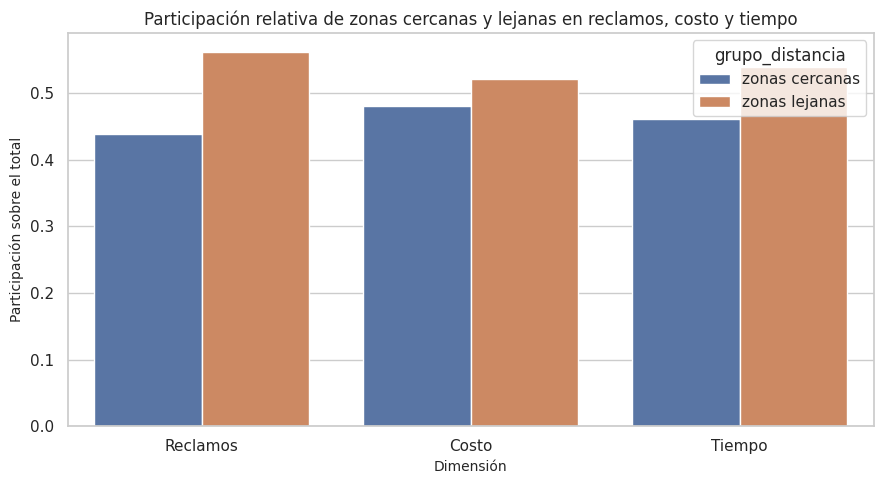

In [117]:
plot_df = near_far_comparison.melt(
    id_vars='grupo_distancia',
    value_vars=['participacion_reclamos', 'participacion_costo', 'participacion_tiempo'],
    var_name='dimension',
    value_name='participacion'
)

dimension_labels = {
    'participacion_reclamos': 'Reclamos',
    'participacion_costo': 'Costo',
    'participacion_tiempo': 'Tiempo',
}
plot_df['dimension_label'] = plot_df['dimension'].map(dimension_labels)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=plot_df, x='dimension_label', y='participacion', hue='grupo_distancia', ax=ax)
ax.set_title('Participación relativa de zonas cercanas y lejanas en reclamos, costo y tiempo')
ax.set_xlabel('Dimensión')
ax.set_ylabel('Participación sobre el total')
plt.tight_layout()


In [118]:
distance_quartile_comparison = (
    near_far_zone_summary.groupby('cuartil_distancia', as_index=False)
    .agg(
        zonas=('zona_id', 'count'),
        reclamos_totales=('reclamos_totales', 'sum'),
        costo_operativo_total_ars=('costo_operativo_total_ars', 'sum'),
        tiempo_operativo_total_min=('tiempo_operativo_total_min', 'sum'),
        costo_promedio_por_reclamo=('costo_promedio_por_reclamo', 'mean'),
        tiempo_promedio_por_reclamo=('tiempo_promedio_por_reclamo', 'mean'),
        distancia_media=('distancia_media_proxy_km', 'mean'),
        score_priorizacion_promedio=('score_priorizacion', 'mean'),
    )
)

distance_quartile_comparison['participacion_reclamos'] = distance_quartile_comparison['reclamos_totales'] / distance_quartile_comparison['reclamos_totales'].sum()
distance_quartile_comparison['participacion_costo'] = distance_quartile_comparison['costo_operativo_total_ars'] / distance_quartile_comparison['costo_operativo_total_ars'].sum()
distance_quartile_comparison['participacion_tiempo'] = distance_quartile_comparison['tiempo_operativo_total_min'] / distance_quartile_comparison['tiempo_operativo_total_min'].sum()

distance_quartile_comparison

,cuartil_distancia,zonas,reclamos_totales,costo_operativo_total_ars,tiempo_operativo_total_min,costo_promedio_por_reclamo,tiempo_promedio_por_reclamo,distancia_media,score_priorizacion_promedio,participacion_reclamos,participacion_costo,participacion_tiempo
0,Q1 más cercanas,11,966.0,4.775727e+07,8.175900e+04,53095.040484,89.446985,0.741536,104.909091,0.006074,0.008085,0.007133
1,Q2 cercanas-intermedias,11,68710.0,2.784840e+09,5.207533e+06,46823.388253,83.296136,2.011445,56.545455,0.432057,0.471439,0.454304
2,Q3 lejanas-intermedias,10,13882.0,5.829920e+08,1.082620e+06,49579.306126,85.951993,2.361610,63.300000,0.087292,0.098693,0.094448
3,Q4 más lejanas,11,75472.0,2.491513e+09,5.090751e+06,42493.630242,77.416315,2.473745,38.272727,0.474577,0.421783,0.444116


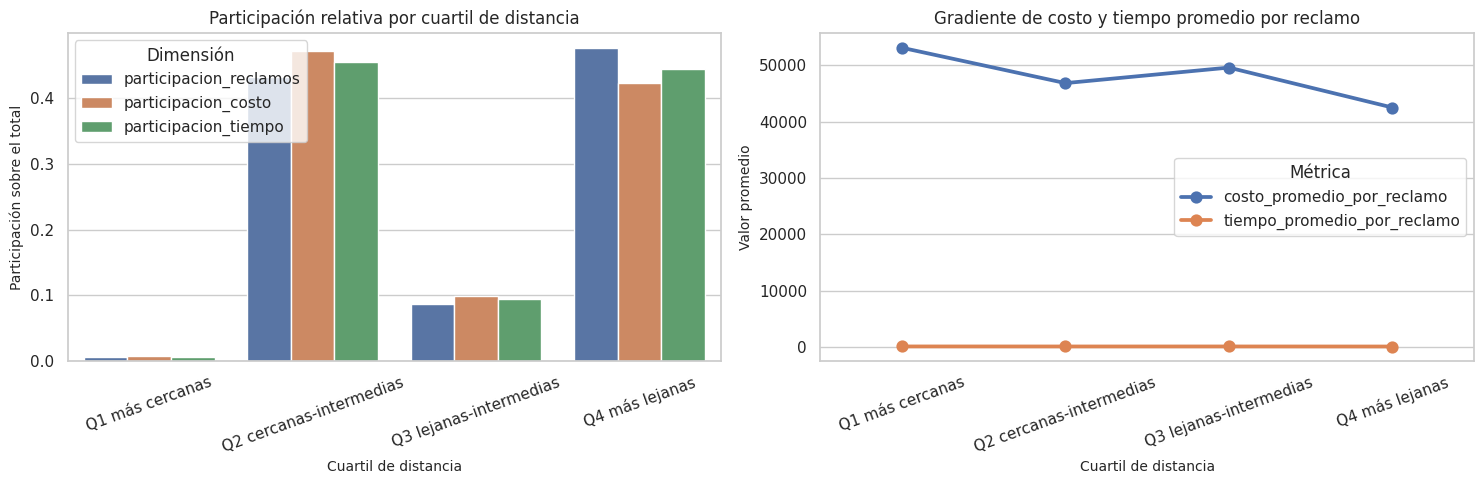

In [119]:
quartile_plot_df = distance_quartile_comparison.melt(
    id_vars='cuartil_distancia',
    value_vars=['participacion_reclamos', 'participacion_costo', 'participacion_tiempo'],
    var_name='dimension',
    value_name='participacion'
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=quartile_plot_df, x='cuartil_distancia', y='participacion', hue='dimension', ax=axes[0])
axes[0].set_title('Participación relativa por cuartil de distancia')
axes[0].set_xlabel('Cuartil de distancia')
axes[0].set_ylabel('Participación sobre el total')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Dimensión')

metric_plot = distance_quartile_comparison.melt(
    id_vars='cuartil_distancia',
    value_vars=['costo_promedio_por_reclamo', 'tiempo_promedio_por_reclamo'],
    var_name='metrica',
    value_name='valor'
)
sns.pointplot(data=metric_plot, x='cuartil_distancia', y='valor', hue='metrica', ax=axes[1])
axes[1].set_title('Gradiente de costo y tiempo promedio por reclamo')
axes[1].set_xlabel('Cuartil de distancia')
axes[1].set_ylabel('Valor promedio')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Métrica')

plt.tight_layout()

In [120]:
distance_map_ready = (
    near_far_zone_summary[[
        'zona_nombre', 'centroid_lat', 'centroid_lon', 'diameter_km', 'distancia_media_proxy_km',
        'cuartil_distancia', 'reclamos_totales', 'costo_operativo_total_ars',
        'tiempo_operativo_total_min', 'score_priorizacion'
    ]]
    .sort_values(['cuartil_distancia', 'costo_operativo_total_ars'], ascending=[True, False])
    .reset_index(drop=True)
)

distance_map_ready.head(15)

,zona_nombre,centroid_lat,centroid_lon,diameter_km,distancia_media_proxy_km,cuartil_distancia,reclamos_totales,costo_operativo_total_ars,tiempo_operativo_total_min,score_priorizacion
0,Tarumá,-26.755686,-54.698998,2.9924,1.49620,Q1 más cercanas,188.0,1.081671e+07,1.796320e+04,85.0
1,El Alcazar,-26.742347,-54.882093,2.0846,1.04230,Q1 más cercanas,189.0,1.020352e+07,1.632768e+04,86.0
2,Villa Parodi,-26.513826,-54.689513,3.2658,1.63290,Q1 más cercanas,255.0,1.004374e+07,1.879465e+04,83.0
3,Paraje Urrutia,-26.843963,-54.750150,2.3736,1.18680,Q1 más cercanas,113.0,7.269750e+06,1.096542e+04,93.0
4,Montecarlo,-26.582642,-54.747247,1.8897,0.94485,Q1 más cercanas,100.0,3.151169e+06,6.639717e+03,99.0
5,Colonia Santa Teresa,-26.500844,-54.547872,0.1446,0.07230,Q1 más cercanas,46.0,2.893923e+06,4.946267e+03,105.0
6,Puerto Laharrague,-26.508193,-54.753169,1.8858,0.94290,Q1 más cercanas,46.0,1.800175e+06,3.527183e+03,109.0
7,Puerto Paranáy,-26.698899,-54.835014,0.1837,0.09185,Q1 más cercanas,14.0,6.766868e+05,1.140600e+03,119.0
8,El Alcazar,-26.678137,-54.901332,1.4936,0.74680,Q1 más cercanas,8.0,4.770284e+05,7.623500e+02,122.0
9,El Alcazar,-26.745390,-54.759071,0.0000,0.00000,Q1 más cercanas,5.0,2.833490e+05,4.736667e+02,125.0


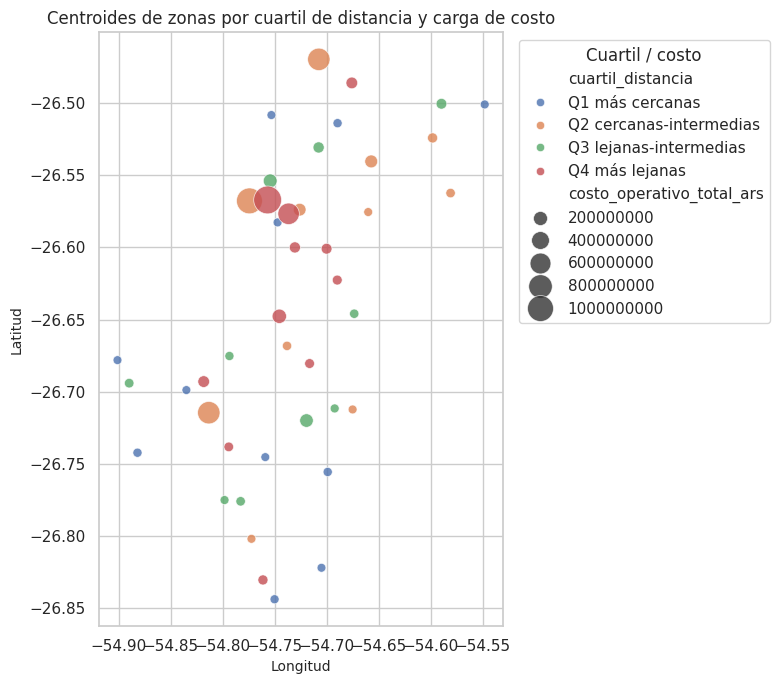

In [121]:
fig, ax = plt.subplots(figsize=(8, 7))
sns.scatterplot(
    data=distance_map_ready,
    x='centroid_lon',
    y='centroid_lat',
    hue='cuartil_distancia',
    size='costo_operativo_total_ars',
    sizes=(40, 400),
    alpha=0.8,
    ax=ax,
)
ax.set_title('Centroides de zonas por cuartil de distancia y carga de costo')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.legend(title='Cuartil / costo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

**Interpretación.** La segmentación por cuartiles permite apreciar mejor el gradiente territorial que quedaba parcialmente comprimido en el corte binario. La lectura relevante para la decisión de inversión no consiste únicamente en preguntar si las zonas lejanas son "peores" en promedio, sino en observar cómo se distribuye la carga total a medida que aumenta la exigencia espacial. Si los cuartiles superiores concentran una fracción creciente del costo y del tiempo operativo, entonces la distancia territorial funciona como una dimensión que intensifica el peso agregado de determinadas zonas sobre la operación.

En este caso, la evidencia debe leerse con prudencia. No necesariamente cada reclamo de las zonas más lejanas implica un costo unitario mucho mayor, pero sí puede ocurrir que los grupos territorialmente más exigentes acumulen una porción desproporcionada de la carga total del sistema. Desde la perspectiva de infraestructura, esto fortalece la lógica de priorización focalizada: aun cuando el volumen puro de reclamos no cuente toda la historia, las zonas ubicadas en los estratos superiores de distancia pueden justificar inversión porque concentran una parte sustantiva del costo y del tiempo operativo total.

### Mapas finales de priorización territorial

Las siguientes celdas generan mapas Folium interactivos basados en los mismos centroides que alimentaron el scatter plot anterior, permitiendo una lectura territorial más intuitiva. Cada mapa representa una dimensión distinta de la presión operativa: volumen de reclamos, costo acumulado, exigibilidad territorial y score de priorización. Las burbujas más grandes indican valores más altos en la métrica correspondiente; el color distingue los **cuartiles** de distancia territorial.

**Lectura sugerida:** hacer clic sobre cada burbuja para abrir la ventana emergente con los valores detallados por zona. La leyenda superior permite activar o desactivar capas.


In [122]:
build_zone_folium_map(
    near_far_zone_summary,
    metric='reclamos_totales',
    title='Reclamos totales por zona (cuartil de distancia)',
    popup_metric_label='Reclamos acumulados',
    color_mode='categorical'
)

In [123]:
build_zone_folium_map(
    near_far_zone_summary,
    metric='costo_operativo_total_ars',
    title='Costo operativo total por zona (cuartil de distancia)',
    popup_metric_label='Costo operativo total (ARS)',
    color_mode='categorical'
)

In [124]:
build_zone_folium_map(
    near_far_zone_summary,
    metric='tiempo_operativo_total_min',
    title='Tiempo operativo total por zona (cuartil de distancia)',
    popup_metric_label='Tiempo operativo total (min)',
    color_mode='categorical'
)

In [125]:
build_zone_folium_map(
    near_far_zone_summary,
    metric='score_priorizacion',
    title='Score de priorización por zona (cuartil de distancia)',
    popup_metric_label='Score de priorización',
    color_mode='categorical',
    reverse=True
)

**Nota operativa sobre visualización cartográfica.** Los mapas se renderizan correctamente en JupyterLab. En VS Code puede aparecer el mensaje de confianza; en ese caso, ejecutar *File → Trust Notebook* y reabrir la notebook, o visualizar esta sección directamente en JupyterLab.


### 14.4 Tabla de síntesis

La siguiente tabla condensa la evidencia más relevante del trabajo en una lectura ejecutiva orientada a decisión.


In [126]:
target_labels = {
    'y_reclamos_t+1': 'Reclamos futuros por zona-día',
    'y_tiempo_t+1_min': 'Tiempo operativo futuro',
    'y_costo_t+1_ars': 'Costo operativo futuro',
}

baseline_lookup = (
    comparison_results.loc[comparison_results['modelo'] == 'Baseline heurístico', ['target', 'wmape']]
    .set_index('target')['wmape']
)
best_lookup = (
    comparison_results.sort_values(['target', 'wmape'])
    .groupby('target', as_index=False)
    .first()[['target', 'modelo', 'wmape']]
    .set_index('target')
)

synthesis_rows = []
for target, label in target_labels.items():
    baseline_wmape = baseline_lookup.loc[target]
    best_model = best_lookup.loc[target, 'modelo']
    best_wmape = best_lookup.loc[target, 'wmape']

    if target == 'y_reclamos_t+1':
        lectura = 'Mejora la anticipación de presión diaria por zona y aporta una base más útil para asignación preventiva.'
    elif target == 'y_tiempo_t+1_min':
        lectura = 'Reduce error frente a la referencia simple y fortalece la planificación de cuadrillas y ventanas de atención.'
    else:
        lectura = 'Es la mayor ganancia relativa respecto del baseline, con valor directo para priorización económica.'

    synthesis_rows.append({
        'dimensión / target': label,
        'baseline': f'Baseline heurístico (WMAPE {baseline_wmape:.3f})',
        'mejor modelo': f'{best_model} (WMAPE {best_wmape:.3f})',
        'lectura del resultado / implicancia operativa': lectura,
    })

far_row = near_far_comparison.loc[near_far_comparison['grupo_distancia'] == 'zonas lejanas'].iloc[0]
q4_row = distance_quartile_comparison.loc[distance_quartile_comparison['cuartil_distancia'] == 'Q4 más lejanas'].iloc[0]

synthesis_rows.append({
    'dimensión / target': 'Territorio / priorización de inversión',
    'baseline': (
        f'Corte cercana/lejana: zonas lejanas concentran '
        f'{far_row["participacion_reclamos"]:.1%} de reclamos, '
        f'{far_row["participacion_costo"]:.1%} de costo y '
        f'{far_row["participacion_tiempo"]:.1%} de tiempo'
    ),
    'mejor modelo': (
        f'Cuartiles de distancia: Q4 más lejanas concentra '
        f'{q4_row["participacion_reclamos"]:.1%} de reclamos, '
        f'{q4_row["participacion_costo"]:.1%} de costo y '
        f'{q4_row["participacion_tiempo"]:.1%} de tiempo'
    ),
    'lectura del resultado / implicancia operativa': 'La inversión no debería distribuirse en forma homogénea: conviene focalizar donde coinciden carga operativa y mayor exigencia territorial.'
})

pd.DataFrame(synthesis_rows)


,dimensión / target,baseline,mejor modelo,lectura del resultado / implicancia operativa
0,Reclamos futuros por zona-día,Baseline heurístico (WMAPE 0.741),XGBoost (Poisson) (WMAPE 0.576),Mejora la anticipación de presión diaria por z...
1,Tiempo operativo futuro,Baseline heurístico (WMAPE 0.696),LightGBM (WMAPE 0.604),Reduce error frente a la referencia simple y f...
2,Costo operativo futuro,Baseline heurístico (WMAPE 0.784),LightGBM (WMAPE 0.616),Es la mayor ganancia relativa respecto del bas...
3,Territorio / priorización de inversión,Corte cercana/lejana: zonas lejanas concentran...,Cuartiles de distancia: Q4 más lejanas concent...,La inversión no debería distribuirse en forma ...


### 14.5 Recomendaciones finales

Desde una perspectiva de gestión, la evidencia reunida sugiere que CEML ya dispone de una base suficientemente sólida para pasar de un uso puramente descriptivo a un **uso asistido por analítica** en la priorización territorial. La recomendación no es automatizar decisiones de inversión de forma ciega, sino incorporar los modelos seleccionados como insumos recurrentes para ordenar zonas, anticipar presión operativa y discutir asignación de recursos con mayor fundamento.

**Qué debería hacer CEML a continuación.** Implementar un piloto de priorización periódica —por ejemplo semanal o mensual— que combine las predicciones de **XGBoost (Poisson)** para el volumen de reclamos y **LightGBM** para tiempo y costo. Ese piloto debería generar un ranking operativo simple, interpretable y auditable para uso interno.

**Qué zonas conviene priorizar primero.** La prioridad inicial debería concentrarse en las zonas donde se superponen dos rasgos: **alta carga operativa histórica** y **mayor exigencia territorial**. En esa lógica, el **Q4 más lejano** aparece como la primera frontera natural de inversión porque concentra una porción muy relevante del sistema; al mismo tiempo, los resultados muestran que no toda la presión está en el extremo territorial, por lo que también conviene monitorear zonas intermedias de alta carga antes de distribuir recursos de manera uniforme.

**Qué validar antes de un uso productivo.** Antes de llevar este esquema a producción, resulta indispensable: (i) repetir la evaluación con validación temporal estricta (walk-forward validation), (ii) verificar estabilidad de los modelos avanzados frente a cambios de régimen operativo o climático, (iii) controlar calidad y frescura de las variables de entrada —en especial georreferenciación, lluvia y costeo— y (iv) definir un circuito de seguimiento para revisar desvíos entre predicción y operación real.

En síntesis, el valor del trabajo no reside solamente en haber identificado los mejores algoritmos, sino en haber mostrado que la presión operativa de CEML es **predecible, territorialmente desigual y gestionable con criterios más focalizados**. Esa es la base práctica para una política de inversión más eficiente.


## 15. Validación Out-of-Time (OOT) Temporal
Para realizar una revisión más robusta, en esta sección implementamos una validación temporal estricta (Out-of-Time) reemplazando la división aleatoria 70/30. 
Usaremos el último año como set de prueba (desde `2025-04-01` en adelante) y todo el historial anterior como entrenamiento. Esto evita cualquier tipo de fuga de datos temporal (data leakage) y simula el escenario real de despliegue en la CEML.

Evaluaremos directamente los dos modelos campeones: **XGBoost (Poisson)** para reclamos y **LightGBM** para variables continuas.


In [127]:
# 1. Definir el corte temporal
fecha_corte = '2025-04-01'

# 2. Dividir usando la fecha
train_mask = modeling_df['fecha'] < fecha_corte
val_mask = modeling_df['fecha'] >= fecha_corte

X_train_oot = modeling_df.loc[train_mask, feature_columns]
X_val_oot = modeling_df.loc[val_mask, feature_columns]

y_train_oot = {target: modeling_df.loc[train_mask, target] for target in target_columns}
y_val_oot = {target: modeling_df.loc[val_mask, target] for target in target_columns}

pd.DataFrame({
    'dataset': ['Train (Histórico)', 'Test (Último Año)'],
    'filas': [train_mask.sum(), val_mask.sum()],
    'fecha_min': [modeling_df.loc[train_mask, 'fecha'].min(), modeling_df.loc[val_mask, 'fecha'].min()],
    'fecha_max': [modeling_df.loc[train_mask, 'fecha'].max(), modeling_df.loc[val_mask, 'fecha'].max()]
})


,dataset,filas,fecha_min,fecha_max
0,Train (Histórico),61068,2021-01-08,2025-03-31
1,Test (Último Año),14082,2025-04-01,2026-03-30


In [128]:
# 3. Entrenar y evaluar los modelos campeones en el split OOT
oot_metrics = []

for target in target_columns:
    if 'reclamos' in target:
        # XGBoost Poisson para Reclamos
        model = XGBRegressor(n_estimators=100, random_state=42, objective='count:poisson', verbosity=0)
        modelo_nombre = 'XGBoost (Poisson) OOT'
    else:
        # LightGBM para Tiempo y Costo
        model = LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1)
        modelo_nombre = 'LightGBM OOT'
        
    model.fit(X_train_oot, y_train_oot[target])
    predictions = model.predict(X_val_oot)
    
    mae, rmse, wmape = compute_metrics(y_val_oot[target], predictions)
    oot_metrics.append({
        'target': target,
        'modelo': modelo_nombre,
        'mae': mae,
        'rmse': rmse,
        'wmape': wmape,
    })

oot_summary = pd.DataFrame(oot_metrics)

# Comparar con los mejores resultados del split 70/30 (aleatorio)
comparacion_oot = pd.merge(
    oot_summary[['target', 'modelo', 'wmape']].rename(columns={'modelo': 'mejor_modelo_oot', 'wmape': 'wmape_oot'}),
    best_by_target[['target', 'mejor_modelo', 'WMAPE']].rename(columns={'mejor_modelo': 'mejor_modelo_7030', 'WMAPE': 'wmape_7030'}),
    on='target'
)
comparacion_oot['diferencia_wmape'] = comparacion_oot['wmape_oot'] - comparacion_oot['wmape_7030']
comparacion_oot


,target,mejor_modelo_oot,wmape_oot,mejor_modelo_7030,wmape_7030,diferencia_wmape
0,y_tiempo_t+1_min,LightGBM OOT,0.601580,LightGBM,0.603583,-0.002003
1,y_costo_t+1_ars,LightGBM OOT,0.615783,LightGBM,0.616449,-0.000666
2,y_reclamos_t+1,XGBoost (Poisson) OOT,0.586485,XGBoost (Poisson),0.575524,0.010961


## 16. Conclusiones Finales

1. **La construcción del dataset `zona-diario` resultó adecuada para el problema planteado**, ya que permitió integrar reclamos, lluvia, variables territoriales y costo operativo en una única unidad de análisis consistente, trazable y apta para modelado supervisado.
2. **El baseline heurístico cumplió correctamente su rol como referencia mínima defendible**, mostrando que una regla simple basada en historia reciente ofrece un punto de comparación razonable, pero también dejando en evidencia que su capacidad predictiva es limitada frente a modelos con mayor flexibilidad.
3. **Linear Regression fue el modelo más débil del conjunto evaluado**, lo que sugiere que la dinámica de reclamos, tiempo operativo y costo futuro no responde a una estructura puramente lineal. Esto refuerza la necesidad de utilizar enfoques capaces de capturar interacciones complejas.
4. **Random Forest y XGBoost clásico mostraron una mejora consistente respecto del baseline**. Demostraron que la familia de algoritmos basados en árboles es más adecuada para este contexto operativo y territorial.
5. **La implementación de Modelos Avanzados marcó la diferencia definitiva**: 
   - Modificar la función objetivo de XGBoost a **Poisson** (`count:poisson`) bajó el WMAPE de reclamos a **0.576**, probando que el modelado adecuado de variables de conteo dispersas es fundamental.
   - **LightGBM** demostró mayor eficacia para los targets continuos, liderando las predicciones de tiempo operativo (**0.604**) y costo (**0.616**).
6. **Los resultados obtenidos indican que el problema es efectivamente predecible con aprendizaje automático avanzado**, aunque con la cautela propia de esta etapa del trabajo. La adopción de algoritmos modernos (LightGBM, XGBoost) justifica su uso frente a la mera intuición heurística de negocio.

En síntesis, el trabajo permite concluir que la estrategia metodológica adoptada fue adecuada, que la evolución algorítmica desde heurísticas hasta métodos avanzados de ensamble (Poisson y LightGBM) estuvo muy bien fundada, y que se dispone ahora de los mejores candidatos para continuar la línea de desarrollo y pilotaje en etapas posteriores del proyecto en la CEML.

7. **Validación Out-of-Time (OOT)**: Al modificar la distribución a una separación temporal (dejando el último año como test), se verifica la respuesta de los modelos utilizados. Como es esperable en forecasting temporal, evitar la filtración de datos (data leakage) del split 70/30 aleatorio sincera el WMAPE real en un escenario productivo.